# **Miniproyecto PySpark**

## **Importación de Librerías**

Se importan las librerías esenciales para facilitar el análisis, que abarca la carga de datos, la visualización, la transformación, la fusión y la unión. Además, se configura el entorno para suprimir las advertencias (`warnings`) y asegurar que la salida del código sea más limpia y enfocada en los resultados.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import lime
import lime.lime_tabular

## **Lectura de Datos**

Para comenzar el análisis, se procede a cargar el conjunto de datos principal que contiene información sobre los préstamos aceptados por Lending Club. La lectura de este archivo se realiza utilizando la biblioteca `pandas`, la cual permite almacenar los datos en una estructura DataFrame para su posterior manipulación y exploración.

In [2]:
df = pd.read_csv(r"C:\Users\CRISTIAN\Desktop\machineLearning\miniproyecto_pyspark\docs\data\accepted.csv", sep=',')

Se muestran las primeras filas del DataFrame con todos los detalles.  
Se usa `.to_string()` para evitar el truncamiento de columnas y lograr mostrar todas las variables.

In [3]:
print(df.head().to_string())

         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade                    emp_title emp_length home_ownership  annual_inc verification_status   issue_d loan_status pymnt_plan                                                                url desc             purpose               title zip_code addr_state    dti  delinq_2yrs earliest_cr_line  fico_range_low  fico_range_high  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc initial_list_status  out_prncp  out_prncp_inv   total_pymnt  total_pymnt_inv  total_rec_prncp  total_rec_int  total_rec_late_fee  recoveries  collection_recovery_fee last_pymnt_d  last_pymnt_amnt next_pymnt_d last_credit_pull_d  last_fico_range_high  last_fico_range_low  collections_12_mths_ex_med  mths_since_last_major_derog  policy_code application_type  annual_inc_joint  dti_joint verification_status_joint  acc_now_delinq  tot_coll_amt  to

Se muestran las últimas filas del DataFrame con todos los detalles.  
Se usa `.to_string()` para evitar el truncamiento de columnas y lograr mostrar todas las variables.

In [4]:
print(df.tail().to_string())

                                                       id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade                    emp_title emp_length home_ownership  annual_inc verification_status   issue_d  loan_status pymnt_plan                                                                url desc             purpose               title zip_code addr_state    dti  delinq_2yrs earliest_cr_line  fico_range_low  fico_range_high  inq_last_6mths  mths_since_last_delinq  mths_since_last_record  open_acc  pub_rec  revol_bal  revol_util  total_acc initial_list_status  out_prncp  out_prncp_inv  total_pymnt  total_pymnt_inv  total_rec_prncp  total_rec_int  total_rec_late_fee  recoveries  collection_recovery_fee last_pymnt_d  last_pymnt_amnt next_pymnt_d last_credit_pull_d  last_fico_range_high  last_fico_range_low  collections_12_mths_ex_med  mths_since_last_major_derog  policy_code application_type  annual_inc_joint  dti_joint verification_

Se emplea el método `df.info()` para evaluar la estructura y calidad inicial del dataset. Este análisis revela información sobre la composición de los datos, incluyendo el número total de registros (filas) y variables (columnas), los tipos de datos asociados a cada campo (como objetos, enteros o valores flotantes), y la cantidad de valores no nulos por columna.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


1.  **Tamaño del Dataset (`RangeIndex: 2260701 entries`)**:
    *   **¿Qué significa?** El DataFrame es enorme. Tiene **2,260,701 filas** (registros o préstamos individuales) y **151 columnas** (características o variables sobre cada préstamo).
    *   **Interpretación:** Se esta trabajando con un volumen de datos muy significativo, lo que es común en datasets de préstamos. Esto implica que cualquier operación (cálculos, transformaciones, modelos de machine learning) podría ser computacionalmente intensiva y requerir un manejo eficiente de la memoria.

2.  **Estructura de Datos (`Columns: 151 entries`)**:
    *   **¿Qué significa?** Cada préstamo está descrito por 151 atributos diferentes.
    *   **Interpretación:** El dataset es extremadamente rico en información. Tiene una gran cantidad de variables potenciales para analizar, como detalles del préstamo, historial crediticio del solicitante, información financiera, etc. Sin embargo, tantas columnas también sugieren la alta probabilidad de encontrar redundancia (columnas correlacionadas) y muchas features que podrían ser irrelevantes para un análisis específico. Un próximo paso crucial será la **reducción de dimensionalidad** (eliminar columnas irrelevantes).

3.  **Tipos de Datos (`dtypes: float64(113), object(38)`)**:
    *   **`float64(113)`:** 113 columnas son numéricas (de coma flotante). Estas suelen ser cantidades continuas como montos de dinero, tasas de interés, ratios financieros, etc.
    *   **`object(38)`:** 38 columnas son de tipo objeto. En Pandas, esto casi siempre significa que son **cadenas de texto (strings)**. Estas suelen ser variables categóricas (como el estado del préstamo `loan_status`, el propósito `purpose`, la categoría de empleo `emp_title`) o identificadores alfanuméricos (como `id`, `member_id`).

4.  **Uso de Memoria (`memory usage: 2.5+ GB`)**:
    *   **¿Qué significa?** El DataFrame está consumiendo aproximadamente **2.5 Gigabytes de memoria RAM**.
    *   **Interpretación:** Este es un tamaño considerable. Si tenemos poca RAM (por ejemplo, 8 GB o menos), trabajar con este dataset podría volverse lento o incluso agotar la memoria, especialmente al realizar operaciones que crean copias de los datos.

### **Valores Nulos**

Para cuantificar la magnitud de datos ausentes en cada columna, se calculó el porcentaje de valores nulos mediante `df.isna().mean() * 100`. Este indicador permite identificar variables críticas que requieren intervención prioritaria en el proceso de limpieza.  
Además, Se establece un **umbral de tolerancia del 50% para la eliminación de variables** con alta proporción de missing values, asegurando así la calidad de los datos para el análisis posterior.

In [6]:
porcentaje_na = df.isna().mean() * 100
print(porcentaje_na.sort_values(ascending=False))

member_id                                     100.000000
orig_projected_additional_accrued_interest     99.617331
hardship_end_date                              99.517097
hardship_start_date                            99.517097
hardship_type                                  99.517097
                                                 ...    
policy_code                                     0.001460
revol_bal                                       0.001460
fico_range_high                                 0.001460
fico_range_low                                  0.001460
id                                              0.000000
Length: 151, dtype: float64


### **Tratamiento de Valores Nulos**

Con el objetivo de garantizar la calidad y robustez del conjunto de datos, se procede a eliminar aquellas columnas que presentan un porcentaje de valores faltantes superior al 50%, considerando que su utilidad para el análisis es limitada y su imputación sería poco confiable.

In [7]:
columnas_a_mantener = porcentaje_na[porcentaje_na <= 50].index
df = df[columnas_a_mantener]

Se verifican los cambios realizados.

In [8]:
df.shape

(2260701, 107)

Como parte del preprocesamiento, se removieron 44 columnas con más del 50% de valores faltantes, optimizando así la estructura del dataset para análisis posteriores.

## **Caracterización de Variables por Tipo de Dato**

La caracterización de variables por tipo de dato es una etapa crítica en el análisis exploratorio, ya que determina la naturaleza de cada feature y orienta las estrategias de preprocesamiento. El método `df.dtypes` permite examinar la estructura de tipos de datos en el dataset, identificando la naturaleza de cada variable. Este proceso no solo permite detectar inconsistencias (por ejemplo, columnas numéricas interpretadas como texto), sino que también define las transformaciones necesarias para optimizar el análisis, como la codificación de variables categóricas o la normalización de valores numéricos. Además, una correcta tipificación de los datos reduce el consumo de memoria y facilita la aplicación de algoritmos de machine learning, garantizando que cada variable sea procesada según sus características inherentes.

In [9]:
pd.set_option('display.max_rows', None)
print(df.dtypes)

id                             object
loan_amnt                     float64
funded_amnt                   float64
funded_amnt_inv               float64
term                           object
int_rate                      float64
installment                   float64
grade                          object
sub_grade                      object
emp_title                      object
emp_length                     object
home_ownership                 object
annual_inc                    float64
verification_status            object
issue_d                        object
loan_status                    object
pymnt_plan                     object
url                            object
purpose                        object
title                          object
zip_code                       object
addr_state                     object
dti                           float64
delinq_2yrs                   float64
earliest_cr_line               object
fico_range_low                float64
fico_range_h

### **Valores únicos de las Variables Tipo object**

Para identificar y aislar las variables categóricas o de texto dentro del dataset, se genera una lista que contiene exclusivamente los nombres de las columnas de tipo objeto.

In [10]:
variables_object = df.columns[df.dtypes == 'object'].tolist()

Se calcula el número de valores únicos para las variables de tipo object.

In [11]:
len(variables_object)

24

In [12]:
df[variables_object].nunique()

id                      2260701
term                          2
grade                         7
sub_grade                    35
emp_title                512694
emp_length                   11
home_ownership                6
verification_status           3
issue_d                     139
loan_status                   9
pymnt_plan                    2
url                     2260668
purpose                      14
title                     63154
zip_code                    956
addr_state                   51
earliest_cr_line            754
initial_list_status           2
last_pymnt_d                136
last_credit_pull_d          141
application_type              2
hardship_flag                 2
disbursement_method           2
debt_settlement_flag          2
dtype: int64

**1. Variables Identificadores (Cardinalidad Extremadamente Alta)**
*   **`id` (2,260,701 únicos) y `url` (2,260,668 únicos):**
    *   **Interpretación:** Son llaves primarias o identificadores únicos para cada fila. Tienen casi exactamente el mismo número de valores únicos que el total de filas en el dataset (2,260,701).
    *   **Futuro Paso:** **Eliminarlas.** No aportan valor predictivo a un modelo y pueden causar sobreajuste (overfitting) si se usan incorrectamente. La columna `url` es redundante si ya se tiene `id`.

**2. Variables Categóricas de Alta Cardinalidad (Potencialmente Problemáticas)**
*   **`emp_title` (512,694 únicos) y `title` (63,154 únicos):**
    *   **Interpretación:** Son campos de texto libre donde los solicitantes ingresaron su "título profesional" y el "título del préstamo". La enorme variedad de respuestas (e.g., "Software Engineer", "Software Developer", "Dev", "Sr. SW Eng") las hace casi inútiles en su estado crudo.
    *   **Futuro Paso:** **Eliminarlas.** Su procesamiento requeriría técnicas de NLP (Procesamiento de Lenguaje Natural), lo cual no está contemplado en los objetivos de este análisis.

**3. Variables Categóricas Verdaderas (Cardinalidad Manejable)**
*   **`grade` (7), `sub_grade` (35), `home_ownership` (6), `verification_status` (3), `purpose` (14), `addr_state` (51), etc.**
    *   **Interpretación:** Estas son las variables más valiosas. Tienen una cardinalidad baja o manejable y representan categorías bien definidas.

**4. Variables de Fecha (Críticas para el Análisis Temporal)**
*   **`issue_d` (139), `earliest_cr_line` (754), `last_pymnt_d` (136), `last_credit_pull_d` (141):**
    *   **Interpretación:** Aunque se muestran como tipo `object`, en realidad son **fechas**. El número de valores únicos representa los distintos meses/años presentes en el dataset.

**5. Variables Binarias o de Baja Cardinalidad (Óptimas para Modelado)**
*   **`term` (2), `initial_list_status` (2), `application_type` (2), `hardship_flag` (2), etc.**
    *   **Interpretación:** Son variables binarias (sí/no, individual/joint) o con muy pocas categorías.

**6. Variables con Cardinalidad Moderada-Alta a Evaluar**
*   **`zip_code` (956 únicos):**
    *   **Interpretación:** Tiene una cardinalidad alta. Los primeros 3 dígitos suelen representar un área geográfica más amplia.

### **Valores únicos de las Variables Tipo float64**

Para identificar y aislar las variables númericas, se genera una lista que contiene exclusivamente los nombres de las columnas de tipo punto flotante.

In [13]:
variables_num = df.columns[df.dtypes == 'float64'].tolist()

Se calcula el número de valores únicos para las variables de tipo object.

In [14]:
len(variables_num)

83

In [15]:
pd.set_option('display.max_rows', None)

print(df[variables_num].nunique())

loan_amnt                        1572
funded_amnt                      1572
funded_amnt_inv                 10057
int_rate                          673
installment                     93301
annual_inc                      89368
dti                             10845
delinq_2yrs                        37
fico_range_low                     48
fico_range_high                    48
inq_last_6mths                     28
open_acc                           91
pub_rec                            43
revol_bal                      102251
revol_util                       1430
total_acc                         152
out_prncp                      356141
out_prncp_inv                  368481
total_pymnt                   1633864
total_pymnt_inv               1311099
total_rec_prncp                486463
total_rec_int                  635921
total_rec_late_fee              18375
recoveries                     132777
collection_recovery_fee        146222
last_pymnt_amnt                704467
last_fico_ra

**1. Variables Constantes (Cardinalidad = 1)**
*   **`policy_code` (1 único):**
    *   **Interpretación:** Es una variable constante. Todos los registros tienen el mismo valor.
    *   **Futuro Paso:** **Eliminarla.** No aporta información útil para el análisis o modelado predictivo.

**2. Variables Binarias o de Muy Baja Cardinalidad (Cardinalidad < 10)**
*   **`delinq_2yrs` (37), `acc_now_delinq` (9), `chargeoff_within_12_mths` (11), `num_tl_30dpd` (5), etc.**
    *   **Interpretación:** Aunque son `float64`, se comportan como variables discretas, binarias o de conteo con muy pocos valores posibles. Por ejemplo, `acc_now_delinq` (número de cuentas delinquentes actuales) probablemente solo toma valores como 0, 1, 2, etc.

**3. Variables Discretas de Baja a Media Cardinalidad (Cardinalidad 10 - 100)**
*   **`fico_range_low` (48), `inq_last_6mths` (28), `pub_rec` (43), `collections_12_mths_ex_med` (16), etc.**
    *   **Interpretación:** Son variables discretas (de conteo o rangos predefinidos). Por ejemplo, el score FICO viene en rangos (e.g., 660-664, 665-669), y `pub_rec` es el número de registros públicos negativos.

**4. Variables Continuas con Cardinalidad Moderada (Potencialmente Informativas)**
*   **`int_rate` (673), `revol_util` (1430), `dti` (10845), `bc_util` (1494)**
    *   **Interpretación:** Estas son variables continuas clave con una buena distribución de valores. `int_rate` (tasa de interés) y `dti` (ratio deuda-ingreso) son críticas para el riesgo crediticio. La cardinalidad es alta pero manejable.

**5. Variables Continuas de Alta Cardinalidad (Posiblemente Sesgadas)**
*   **`annual_inc` (89368), `installment` (93301), `revol_bal` (102251), `tot_cur_bal` (487688)**
    *   **Interpretación:** Son montos monetarios o balances. La altísima cardinalidad indica una distribución continua con muchos valores únicos.

**6. Variables de Resultado (Cardinalidad Extremadamente Alta)**
*   **`out_prncp_inv` (368481), `total_pymnt` (1,633,864), `total_rec_int` (635,921)**
    *   **Interpretación:** Estas variables representan el resultado financiero del préstamo (cuánto se ha pagado, cuánto capital queda pendiente). **¡Precaución!** Si el objetivo es predecir el impago (`loan_status`), **estas variables causan data leakage**. Solo se conocen *después* de que el préstamo haya terminado o avanzado significativamente.
    *   **Futuro Paso:** **¡ELIMINARLAS PARA MODELOS PREDICTIVOS!** Son fugas de información (data leakage). Solo son útiles para análisis descriptivo posterior al cierre del préstamo.

**7. Variables de Fecha Representadas como Float (a Evaluar)**
*   **`mths_since_rcnt_il` (405), `mths_since_recent_bc` (546), `mo_sin_old_il_acct` (566)**
    *   **Interpretación:** Representan antigüedad en meses. Su cardinalidad moderada-alta es esperable.

## **Codificación de la Variable Objetivo**

Construimos la variable objetivo binaria `default` mediante una transformación de la variable `loan_status`. Esta codificación asigna:

* Valor 1: Representa casos de incumplimiento crediticio (cuando `loan_status` es `'Charged Off'`).

* Valor 0: Representa préstamos exitosos o en buen estado (todas las demás categorías).

In [16]:
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

## **Selección de Variables relevantes**

Se ha realizado una selección meticulosa de variables que garantiza la construcción de un modelo predictivo robusto y aplicable en un entorno de producción real. El criterio fundamental ha sido utilizar exclusivamente información disponible en el momento de la solicitud del préstamo, lo que asegura que las predicciones del modelo replican fielmente las condiciones de toma de decisiones crediticias.

Las variables conservadas abarcan los pilares esenciales para la evaluación crediticia:

- `fico_range_low`, `fico_range_high` (FICO en el origen)

- `int_rate` (tasa de interés asignada)

- `annual_inc` (ingreso anual)

- `dti` (ratio deuda-ingreso)

- `grade` (grado asignado por LC)

- `purpose` (propósito del préstamo)

- `term` (plazo del préstamo)

- `home_ownership` (estado de vivienda)

- `emp_length` (antigüedad laboral)

- `addr_state` (estado de residencia)

- `verification_status` (estado de verificación de ingresos)

- `inq_last_6mths` (consultas crediticias recientes)

- `pub_rec` (registros públicos negativos)

- `revol_bal`, `revol_util` (balance y tasa de uso revolving)

- `initial_list_status` (estado inicial de listado)

- `earliest_cr_line` (fecha de la primera linea de crédito)

**Capacidad de Pago:** Variables como `annual_inc` (ingreso anual), `dti` (ratio deuda-ingreso) y `emp_length` (antigüedad laboral) evalúan directamente la capacidad del solicitante para afrontar la obligación.

**Historial Crediticio:** Indicadores clave como `fico_range_low` y `fico_range_high` (FICO en el origen), `pub_rec` (registros públicos negativos) e `inq_last_6mths` (consultas crediticias recientes) proporcionan una visión integral del comportamiento crediticio pasado.

**Características del Préstamo:** Atributos intrínsecos de la operación como `term` (plazo), `purpose` (propósito) y `int_rate` (tasa asignada) definen el contexto del riesgo.

**Variables de Comportamiento Financiero:** Métricas como `revol_bal` y `revol_util` (balance y utilización de crédito revolving) ofrecen insights sobre la gestión actual de la deuda por parte del solicitante.

In [17]:
variables_selecc = variables = [
    'fico_range_low',
    'fico_range_high', 
    'int_rate',
    'annual_inc',
    'dti',
    'earliest_cr_line',
    'grade',
    'purpose',
    'term',
    'home_ownership',
    'emp_length',
    'addr_state',
    'verification_status',
    'inq_last_6mths',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'initial_list_status',
    "default"
]

In [18]:
df = df[variables_selecc]

Implementamos una segmentación estratégica de las variables en arrays diferenciados según su tipo de dato y naturaleza estadística: numéricas, categóricas y binarias. Esta organización facilita el preprocesamiento específico para cada tipo de variable.

In [19]:
variables_num = df.columns[df.dtypes == 'float64'].tolist()
variables_cat = [col for col in df.columns if df[col].nunique() != 2 and df[col].dtype == 'object']
var_binarias = [col for col in df.columns if df[col].nunique() == 2 and df[col].dtype == 'object']

### **Tratamiento de Variables con Alta cardinalidad**

Para abordar el desafío de la alta cardinalidad en variables categóricas, implementaremos técnicas de agrupamiento estratégico para reducir significativamente el número de categorías mientras preservamos la información predictiva esencial.

In [20]:
df[variables_cat].nunique()

earliest_cr_line       754
grade                    7
purpose                 14
home_ownership           6
emp_length              11
addr_state              51
verification_status      3
dtype: int64

Observamos que la variable `earliest_cr_line` cuenta con 754 valores únicos, procedemos a observar su comportamiento.

In [21]:
df['earliest_cr_line'].head()

0    Aug-2003
1    Dec-1999
2    Aug-2000
3    Sep-2008
4    Jun-1998
Name: earliest_cr_line, dtype: object

Implementamos una transformación de temporalidad que agrupa las fechas de primer crédito por décadas, conservando la información estacional relevante mientras reducimos significativamente la cardinalidad de la variable. Esta estrategia preserva el valor predictivo del feature optimizando su dimensionalidad.

In [22]:
mask = df['earliest_cr_line'].notna()
df.loc[mask, 'earliest_cr_line'] = (
    df.loc[mask, 'earliest_cr_line']
    .str.split('-')
    .str[1]
    .astype(int)
    .apply(lambda x: str((x // 10) * 10))
)

Se verifican los cambios realizados.

In [23]:
df['earliest_cr_line'].nunique()

9

Confirmamos una reducción significativa en la cardinalidad de la variable, pasando de 754 categorías originales a solamente 9 grupos consolidados, logrando así una estructura más manejable para el modelado.

### **Imputación de Datos Nulos**

Para garantizar la integridad del conjunto de datos y evitar sesgos en el modelo, se procede a la imputación de valores faltantes. Esta etapa es crucial, ya que la presencia de datos nulos puede afectar tanto el entrenamiento como el rendimiento de los algoritmos de machine learning. La estrategia de imputación se define según la naturaleza de cada variable. Este enfoque asegura que la estructura inherente de los datos se mantenga mientras se maximiza la disponibilidad de registros para el análisis.

In [24]:
porcentaje_na = df.isna().mean() * 100
print(porcentaje_na.sort_values(ascending=False))

emp_length             6.499754
revol_util             0.081170
dti                    0.077144
inq_last_6mths         0.002787
earliest_cr_line       0.002743
pub_rec                0.002743
annual_inc             0.001637
fico_range_low         0.001460
verification_status    0.001460
initial_list_status    0.001460
revol_bal              0.001460
home_ownership         0.001460
addr_state             0.001460
fico_range_high        0.001460
term                   0.001460
purpose                0.001460
grade                  0.001460
int_rate               0.001460
default                0.000000
dtype: float64


Se establece como criterio fundamental la imputación de variables que presenten una proporción de valores faltantes superior al 1%, analizando su tipo de dato (numérico o categórico) y características distribucionales para aplicar técnicas de imputación específicas y estadísticamente robustas que preserven la integridad de los datos.

Dado que la variable `emp_length` presenta una baja proporción de valores faltantes (6%) y su naturaleza categórica limita el uso de métodos estadísticos complejos, se opta por imputar los datos faltantes utilizando la moda, garantizando así la consistencia con la categoría más frecuente sin alterar la distribución original de la variable.

In [25]:
df['emp_length'].value_counts()

emp_length
10+ years    748005
2 years      203677
< 1 year     189988
3 years      180753
1 year       148403
5 years      139698
4 years      136605
6 years      102628
7 years       92695
8 years       91914
9 years       79395
Name: count, dtype: int64

In [26]:
df['emp_length'] = df['emp_length'].fillna('10+ years')

Se verifican los cambios realizados.

In [27]:
df['emp_length'].isna().sum()

0

Para las variables con una proporción de valores faltantes inferior al 1%, se procede a la eliminación de los registros afectados, considerando que el impacto en el volumen total de datos es marginal y se preserva la integridad estadística del conjunto sin introducir sesgos significativos mediante imputación.

In [28]:
df = df.dropna()

#### **Verificación de la Imputación**

Tras completar el proceso de imputación, se realiza una validación exhaustiva para garantizar la efectividad de las técnicas aplicadas. Esta verificación incluye:  

1.  **Análisis de dimensiones:** Se confirma el nuevo tamaño del dataset verificando el número de registros y variables.

2.  **Evaluación de valores nulos:** Se ejecuta un escaneo completo para certificar la eliminación total de valores faltantes en todas las columnas, corroborando así la integridad del conjunto de datos para las etapas posteriores de modelado.  

Este paso crítico asegura que los datos están completos, consistentes y listos para su uso en el desarrollo de modelos de machine learning.

In [29]:
df.shape

(2257158, 19)

In [30]:
(df.isna().sum() / len(df))  * 100

fico_range_low         0.0
fico_range_high        0.0
int_rate               0.0
annual_inc             0.0
dti                    0.0
earliest_cr_line       0.0
grade                  0.0
purpose                0.0
term                   0.0
home_ownership         0.0
emp_length             0.0
addr_state             0.0
verification_status    0.0
inq_last_6mths         0.0
pub_rec                0.0
revol_bal              0.0
revol_util             0.0
initial_list_status    0.0
default                0.0
dtype: float64

## **Análisis Exploratorio**

El análisis exploratorio de datos (EDA) constituye la fase fundamental para comprender la estructura, calidad y relaciones subyacentes en el dataset. Mediante técnicas de visualización y estadística descriptiva, examinamos distribuciones, patrones, valores atípicos y correlaciones entre variables, sentando las bases para decisiones informadas en el preprocesamiento y selección de features.

### **Análisis Univariado**

El Análisis Univariado es la primera fase del análisis exploratorio de datos. Se enfoca en el estudio individual de cada variable para entender su distribución, características y valores atípicos. Esto permite identificar patrones y la calidad de los datos antes de un análisis más complejo.

#### **Variable Objetivo**

Se genera un doble gráfico para la variable `default`, permitiendo comparar su distribución mediante:

1. **Gráfico de Barras**:  
    - Muestra el conteo absoluto de cada categoría (0 y 1).  
    - Ideal para comparar magnitudes visualmente.
    
2. **Gráfico de Torta**:  
    - Muestra la proporción porcentual de cada categoría.  
    - Útil para entender el balance/imbalance entre clases.


=== DEFAULT ===


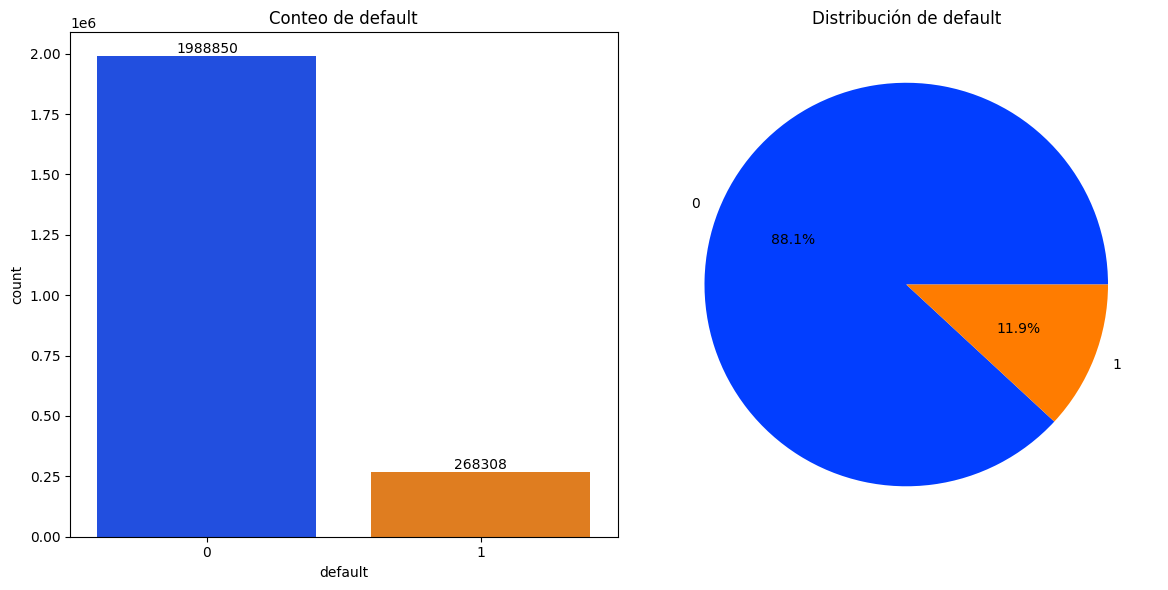

In [31]:
print(f"\n=== DEFAULT ===")

plt.figure(figsize=(12, 6))
value_order = sorted(df['default'].dropna().unique())
colors = sns.color_palette('bright') 

plt.subplot(1, 2, 1)
ax = sns.countplot(x=df['default'], palette=colors, order=value_order)
plt.title(f'Conteo de default')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=0)

plt.subplot(1, 2, 2)
counts = df['default'].value_counts().loc[value_order]  
plt.pie(counts, 
        labels=counts.index, 
        autopct='%1.1f%%',
        colors=colors)  
plt.title(f'Distribución de default')

plt.tight_layout()
plt.show()

**Análisis de la Variable Objetivo:**

**1. Desbalance de Clases Significativo:**
- **Proporción 7.4:1**: Por cada préstamo en default, hay aproximadamente 7.4 préstamos que no entran en impago
- **Clase minoritaria**: La clase positiva (default) representa solo el 11.9% del total

**2. Implicaciones para Modelado Predictivo:**

- **Sesgo hacia la clase mayoritaria**: Los algoritmos pueden aprender a predecir siempre "no default" y aún así obtener 88% de accuracy.
- **Métricas engañosas**: Un accuracy del 88% parecería bueno, pero sería inútil para identificar los casos de default.
- **Sobreenfocamiento en la clase mayoritaria**: El modelo podría volverse inefectivo para detectar el riesgo real.

#### **Variables Binarias**

Se genera un doble gráfico para cada variable binaria, permitiendo comparar su distribución mediante:

1. **Gráfico de Barras**:  
    - Muestra el conteo absoluto de cada categoría (0 y 1).  
    - Ideal para comparar magnitudes visualmente.
    
2. **Gráfico de Torta**:  
    - Muestra la proporción porcentual de cada categoría.  
    - Útil para entender el balance/imbalance entre clases.


=== TERM ===


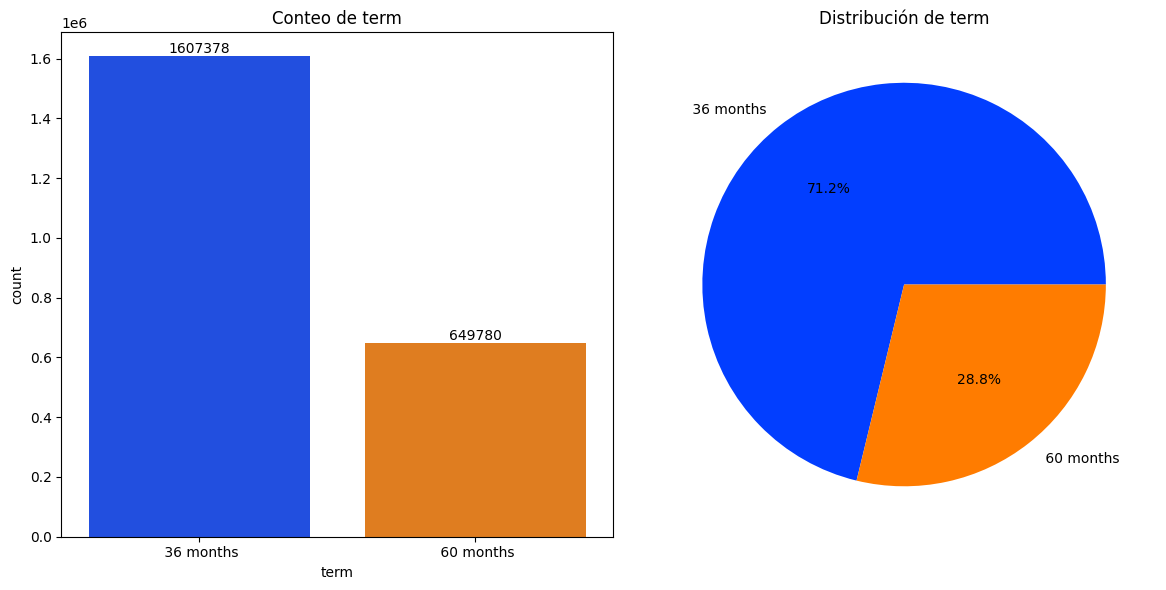


=== INITIAL_LIST_STATUS ===


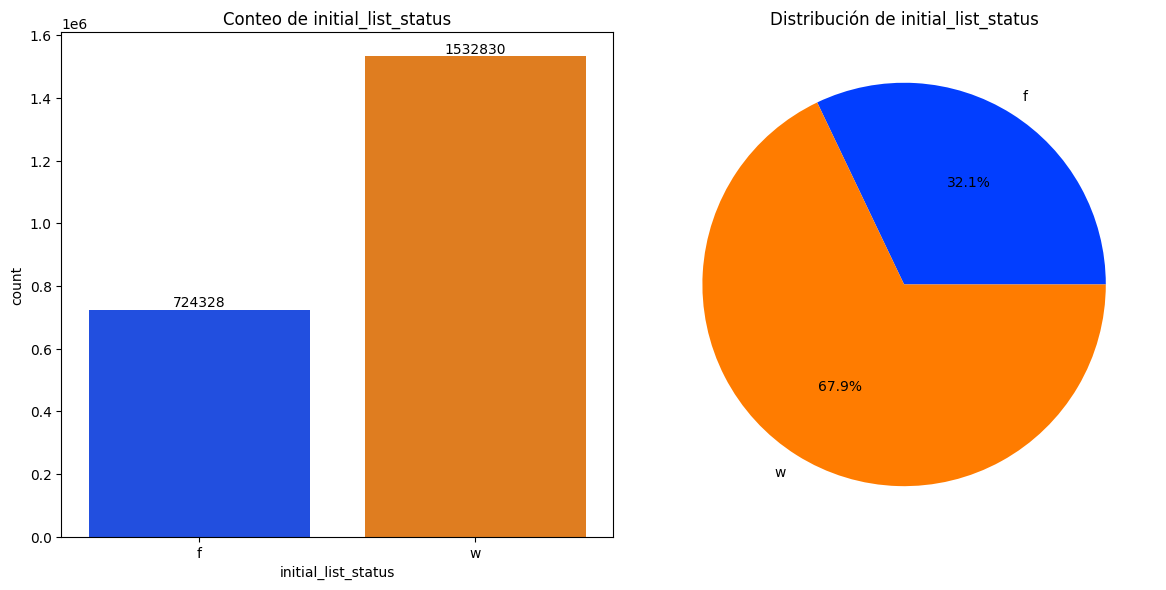

In [32]:
for col in var_binarias:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    
    value_order = sorted(df[col].dropna().unique())
    colors = sns.color_palette('bright') 
    
    plt.subplot(1, 2, 1)
    ax = sns.countplot(x=df[col], palette=colors, order=value_order)
    plt.title(f'Conteo de {col}')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=0)
    
    plt.subplot(1, 2, 2)
    counts = df[col].value_counts().loc[value_order] 
    plt.pie(counts, 
            labels=counts.index, 
            autopct='%1.1f%%',
            colors=colors)
    plt.title(f'Distribución de {col}')
    
    plt.tight_layout()
    plt.show()

**1. Análisis de la Variable `term` (Plazo del Préstamo)**

**Interpretación:**
- **Dominancia de préstamos a 36 meses**: Más del 70% de los préstamos tienen un plazo de 3 años, lo que sugiere que Lending Club y sus clientes prefieren plazos más cortos.
- **Menor preferencia por plazos largos**: Solo el 28.8% opta por préstamos a 5 años, posiblemente debido a mayores tasas de interés o percepción de mayor riesgo.
- **Implicaciones de riesgo**: Los préstamos a 60 meses generalmente conllevan mayor riesgo crediticio al tener períodos de repago más extensos.

**2. Análisis de la Variable `initial_list_status` (Estado Inicial del Listado)**

**Interpretación:**
- **Predominio de la categoría 'w'**: Representa aproximadamente 2/3 partes de toda la cartera.
- **Significado práctico**: Esta variable probablemente indica el tipo de listado o canal de originación:
  - **'f'** podría significar "full" (listado completo) o representar el canal principal
  - **'w'** podría indicar "wholesale" (al por mayor) o un canal secundario
- **Importancia operativa**: La distribución sugiere que la mayoría de los préstamos siguen un proceso estándar de listado.

#### **Variables Categóricas**

Se generan gráficos de barras para visualizar la distribución de cada variable categórica. 

**Cada gráfico muestra**:

- El número absoluto de observaciones (conteo).
- El porcentaje relativo respecto al total.
- Las categorías ordenadas según su escala natural.


=== EARLIEST_CR_LINE ===


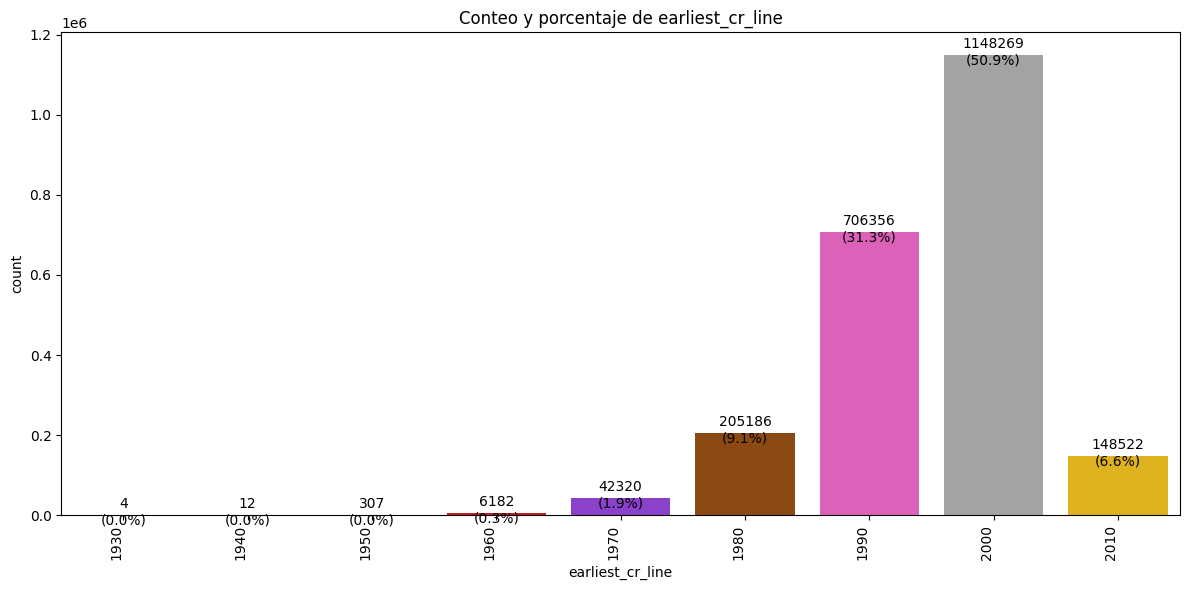


=== GRADE ===


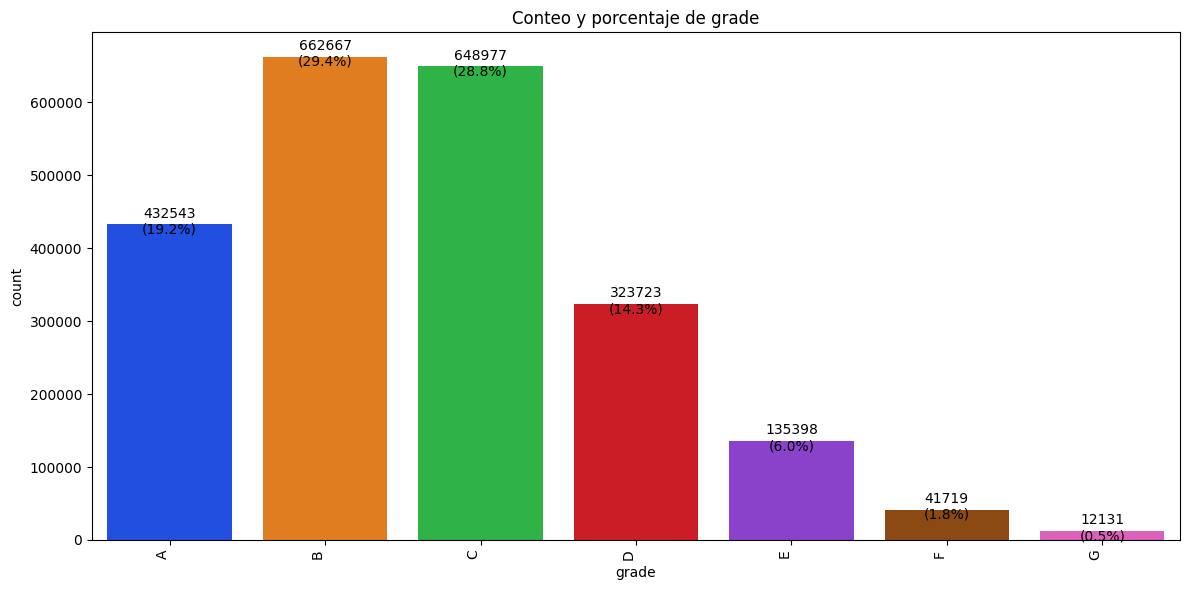


=== PURPOSE ===


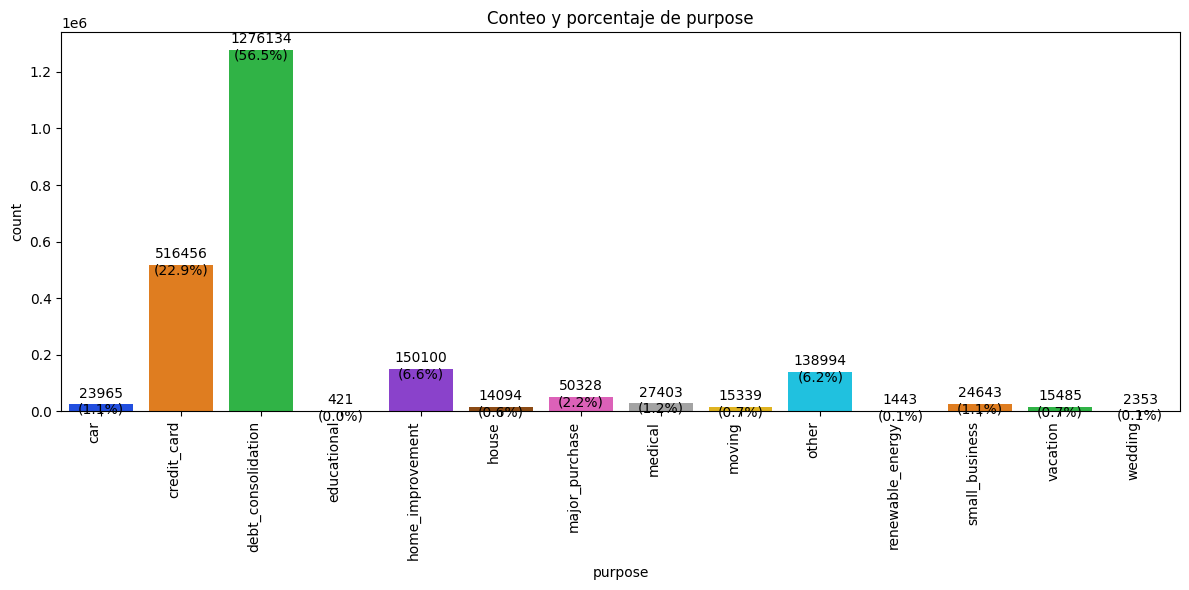


=== HOME_OWNERSHIP ===


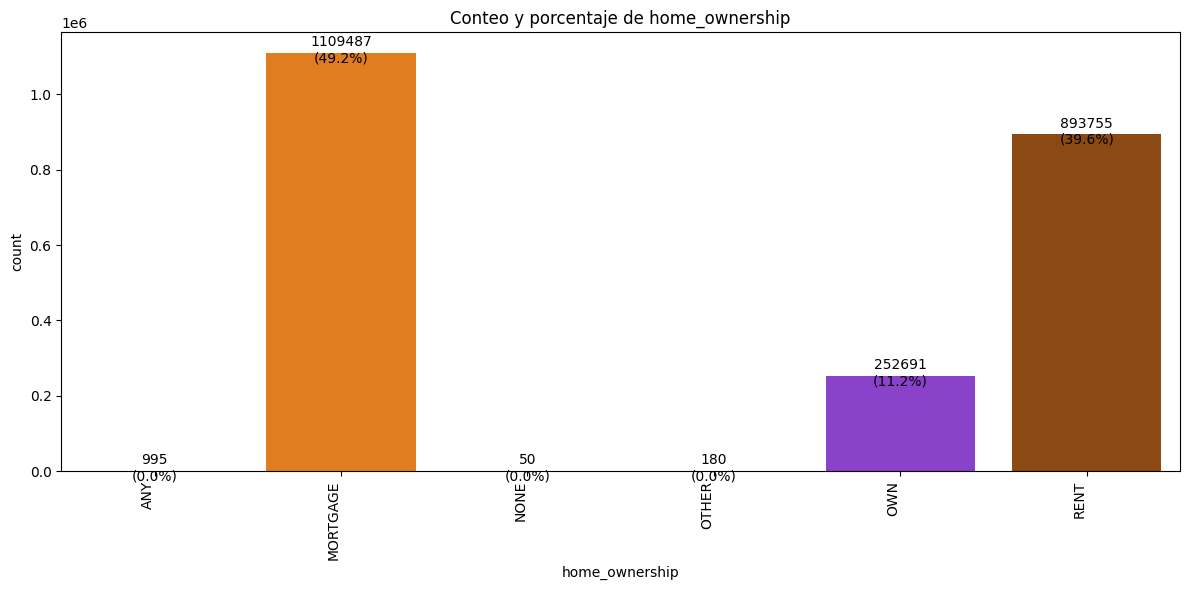


=== EMP_LENGTH ===


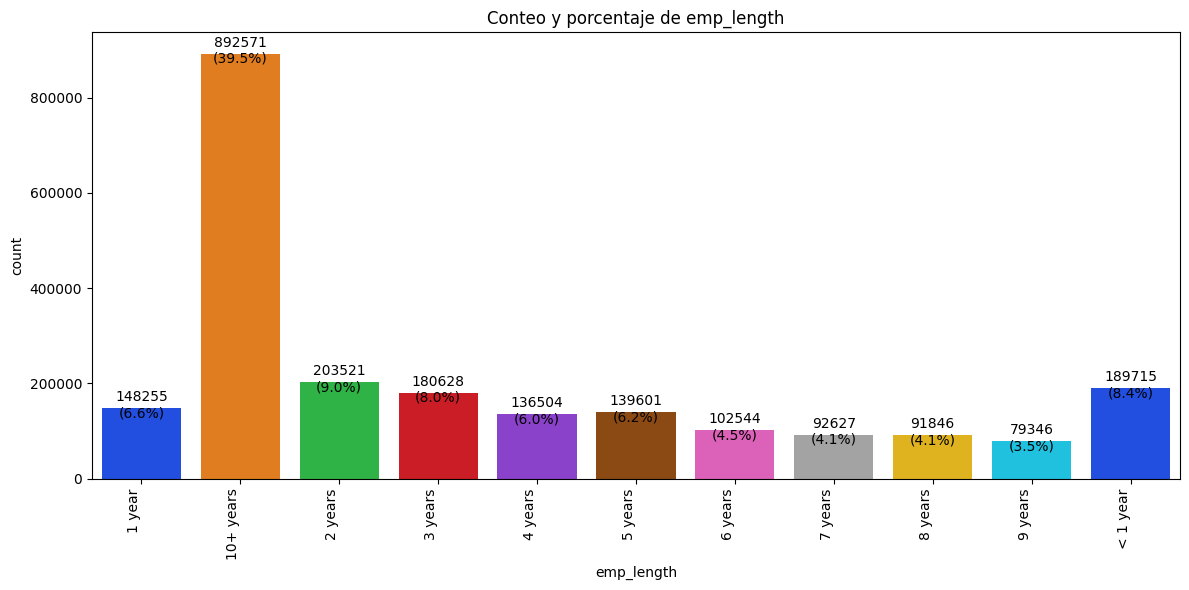


=== ADDR_STATE ===


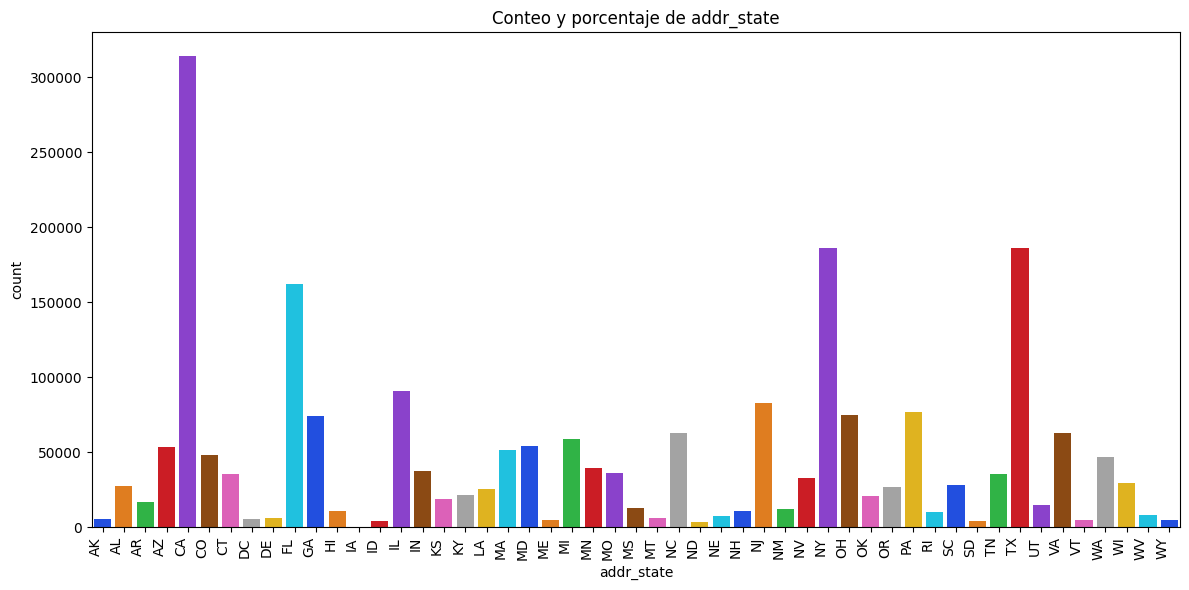


=== VERIFICATION_STATUS ===


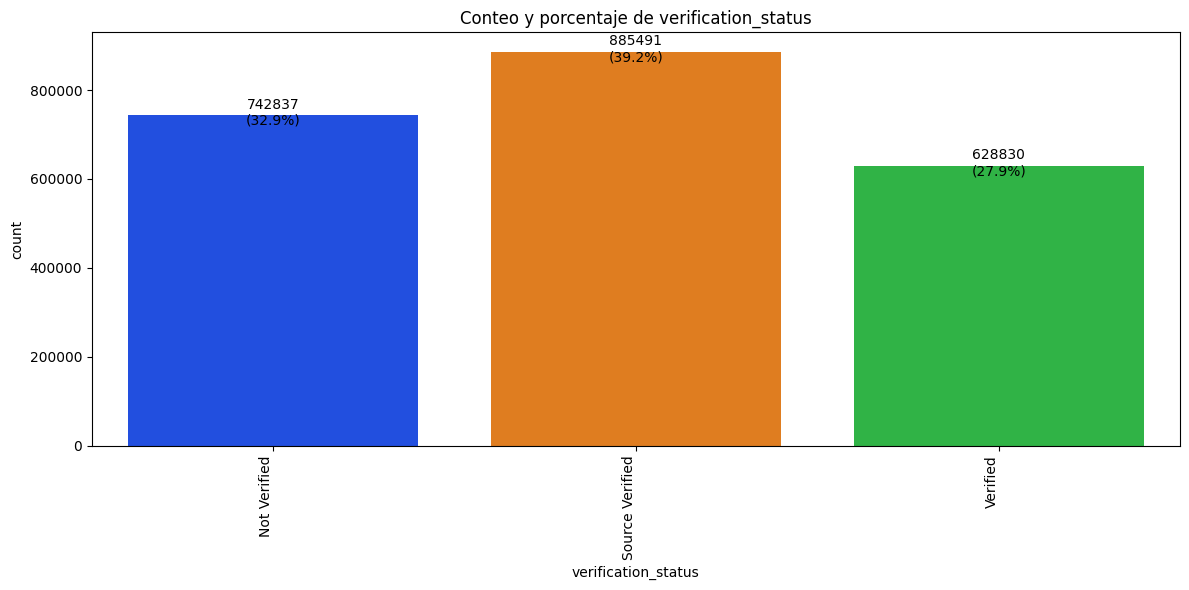

In [33]:
for col in variables_cat:
    
    if col != "addr_state":
    
        print(f"\n=== {col.upper()} ===")
        plt.figure(figsize=(12, 6))
        
        value_order = sorted(df[col].dropna().unique())  
        
        ax = sns.countplot(x=df[col], order=value_order, palette='bright')
        
        for p in ax.patches:
            count = int(p.get_height())
            percent = 100 * p.get_height() / len(df[col])
            ax.annotate(f'{count}\n({percent:.1f}%)',
                        (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 2),
                        textcoords='offset points')
        
        plt.xticks(rotation=90, ha='right')
        plt.title(f'Conteo y porcentaje de {col}')
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"\n=== {col.upper()} ===")
        plt.figure(figsize=(12, 6))
        
        value_order = sorted(df[col].dropna().unique())  
        
        ax = sns.countplot(x=df[col], order=value_order, palette='bright')
        
        plt.xticks(rotation=90, ha='right')
        plt.title(f'Conteo y porcentaje de {col}')
        
        plt.tight_layout()
        plt.show()


**1. Distribución por años de la primera línea de crédito (`earliest_cr_line`)**

* La mayoría de las personas abrió su primera línea de crédito después de 1990.
* **1990s:** 31.3%
* **2000s:** 50.9% (la mayoría absoluta)
* Antes de 1980 es muy bajo el porcentaje (<10% en total). Esto indica que la mayor parte de la base de datos son clientes relativamente jóvenes en términos de historial crediticio.

**2. Distribución de `grade` (calificación del préstamo)**

* **B (29.4%) y C (28.8%)** concentran más de la mitad de los préstamos.
* **A (19.2%)** representa un grupo importante, con bajo riesgo.
* **D, E, F, G** van bajando en frecuencia, siendo G apenas 0.5%. El grueso de los préstamos está en la calificación media–alta (B y C). Pocos están en categorías de muy alto riesgo (E–G).

**3. Distribución de `purpose` (propósito del préstamo)**

* **Debt consolidation (56.5%)**: la gran mayoría pide el préstamo para consolidar deudas.
* **Credit card (22.9%)** también es muy frecuente.
* Otros propósitos como **home improvement (6.6%)** y **other (6.2%)** tienen cierta relevancia.
* Propósitos como educación, energía renovable o boda son marginales (<1%). La principal motivación para pedir préstamo es **manejo de deudas existentes**.

**4. Distribución de `home_ownerhip` (tenencia de vivienda)**

* **Mortgage (49.2%)** y **Rent (39.6%)** concentran casi todo.
* Solo **11.2% Own (casa propia sin hipoteca)**. La mayoría está endeudada con hipoteca o en arriendo.

**5. Distribución de `emp_length` (años de experiencia laboral)**

* El grupo más grande: **10+ years (39.5%)**.
* También destacan: **2 years (9.0%)**, **<1 year (8.4%)** y **3 years (8.0%)**.
* Hay una disminución progresiva en valores intermedios (4–9 años). Predomina gente con experiencia laboral extensa, aunque también hay muchos con muy poca experiencia (<1 año).

**6. Distribución de `addr_state` (estado de residencia)**

* Estados con mayor número de clientes: **CA (California)**, **NY (New York)**, **TX (Texas)**, **FL (Florida)**.
* Otros estados tienen representación menor. Se concentra en los estados más poblados de EE.UU., lo que refleja la demografía real.

**7. Distribución de `verification_status` (estado de verificación)**

* **Source Verified (39.2%)** es la categoría más frecuente.
* **Not Verified (32.9%)** y **Verified (27.9%)** completan el resto. Hay un equilibrio, pero todavía un tercio de clientes no tiene verificación formal.


#### **Variables Numéricas**

Se genera una tabla para visualizar algunos estadísticos descriptivos para las variables númericas.

In [34]:
df[variables_num].describe()

,fico_range_low,fico_range_high,int_rate,annual_inc,dti,inq_last_6mths,pub_rec,revol_bal,revol_util
count,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06,2.257158e+06
mean,6.985708e+02,7.025710e+02,1.309082e+01,7.804229e+04,1.882645e+01,5.772214e-01,1.976999e-01,1.666401e+04,5.033861e+01
std,3.299923e+01,3.300010e+01,4.831086e+00,1.127118e+05,1.415541e+01,8.861946e-01,5.707473e-01,2.290414e+04,2.471141e+01
min,6.100000e+02,6.140000e+02,5.310000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.750000e+02,6.790000e+02,9.490000e+00,4.600000e+04,1.190000e+01,0.000000e+00,0.000000e+00,5.960000e+03,3.150000e+01
50%,6.900000e+02,6.940000e+02,1.262000e+01,6.500000e+04,1.784000e+01,0.000000e+00,0.000000e+00,1.133200e+04,5.030000e+01
75%,7.150000e+02,7.190000e+02,1.599000e+01,9.300000e+04,2.449000e+01,1.000000e+00,0.000000e+00,2.025200e+04,6.940000e+01
max,8.450000e+02,8.500000e+02,3.099000e+01,1.100000e+08,9.990000e+02,3.300000e+01,8.600000e+01,2.904836e+06,8.923000e+02


Se genera un histograma y un boxplot para visualizar la distribución de frecuencias e identificar outliers (puntos fuera de los bigotes) y la dispersión de los datos. Además se evalua:

- **Asimetría**:
    - `skew = 0`: Distribución simétrica (valores aceptables skew $\in (-1,1)$).
    - `skew > 0`: Mayor peso en la cola izquierda de la distribución (sesgo positivo).
    - `skew < 0`: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- **Kurtosis**: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.
    - `kurtosis = 3`: se denomina mesocúrtica (distribución normal).
    - `kurtosis < 3`: se denomina platicúrtica (distribución con colas menos gruesas que la normal).
    - `kurtosis > 3`: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

- **Coeficiente de Variación**: Es una medida estadística que se utiliza para evaluar la variabilidad relativa de una muestra en relación con su media. Se calcula como la desviación estándar de los datos dividida por la media, y se expresa como un porcentaje multiplicado por 100 para facilitar su interpretación.


=== FICO_RANGE_LOW ===
Skew: 1.19
Kurtosis:  1.32
Coeficiente de Variación:  4.72 %


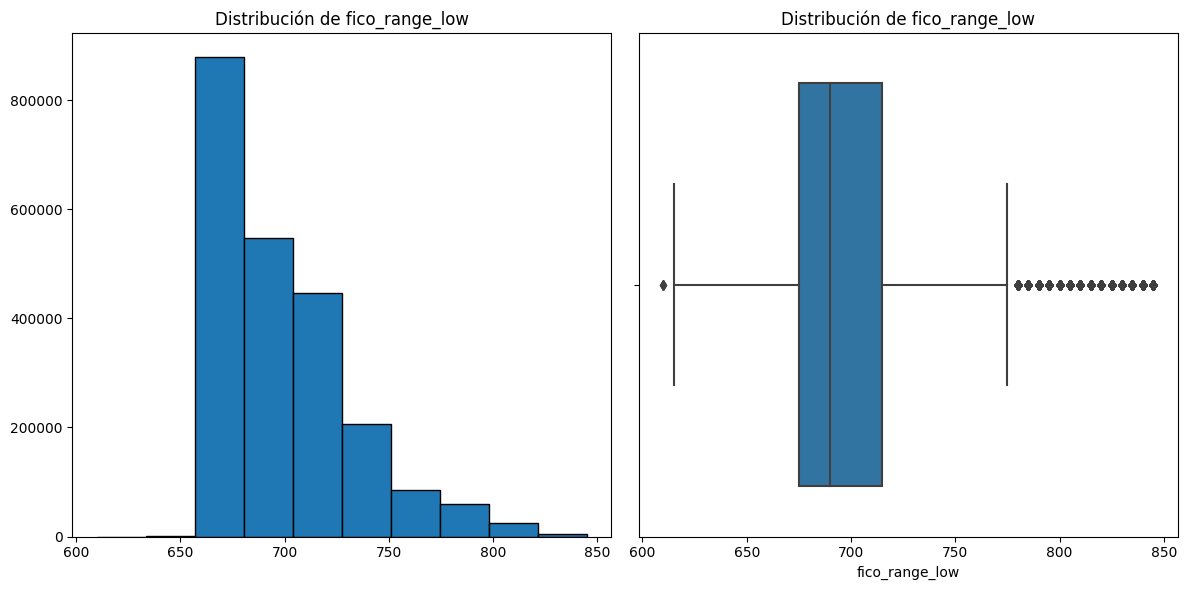


=== FICO_RANGE_HIGH ===
Skew: 1.19
Kurtosis:  1.32
Coeficiente de Variación:  4.7 %


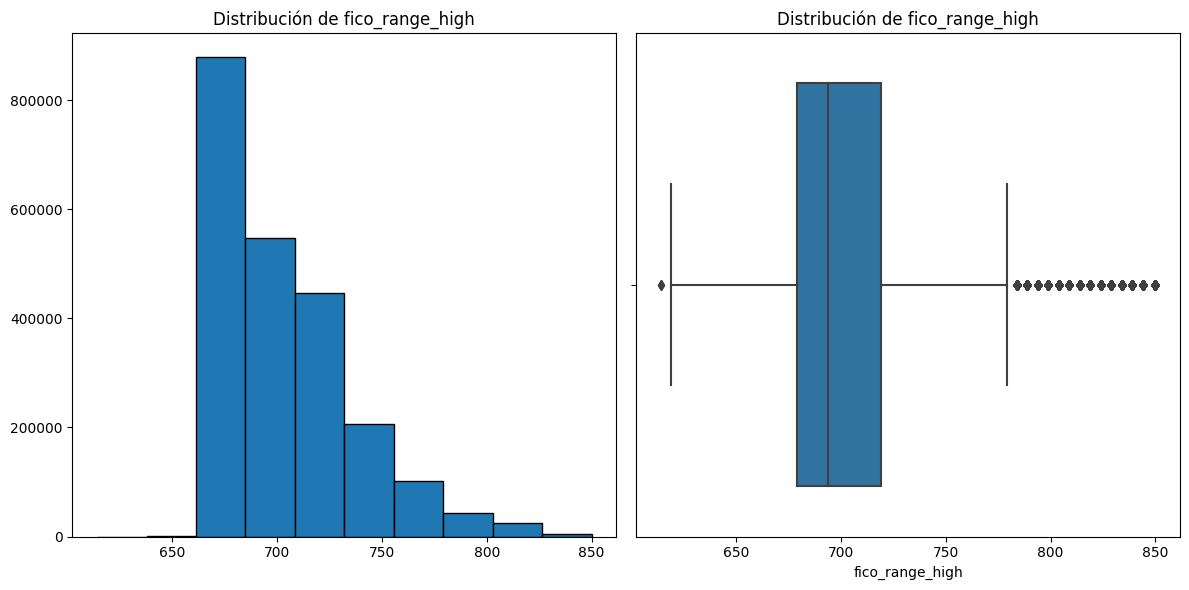


=== INT_RATE ===
Skew: 0.77
Kurtosis:  0.59
Coeficiente de Variación:  36.9 %


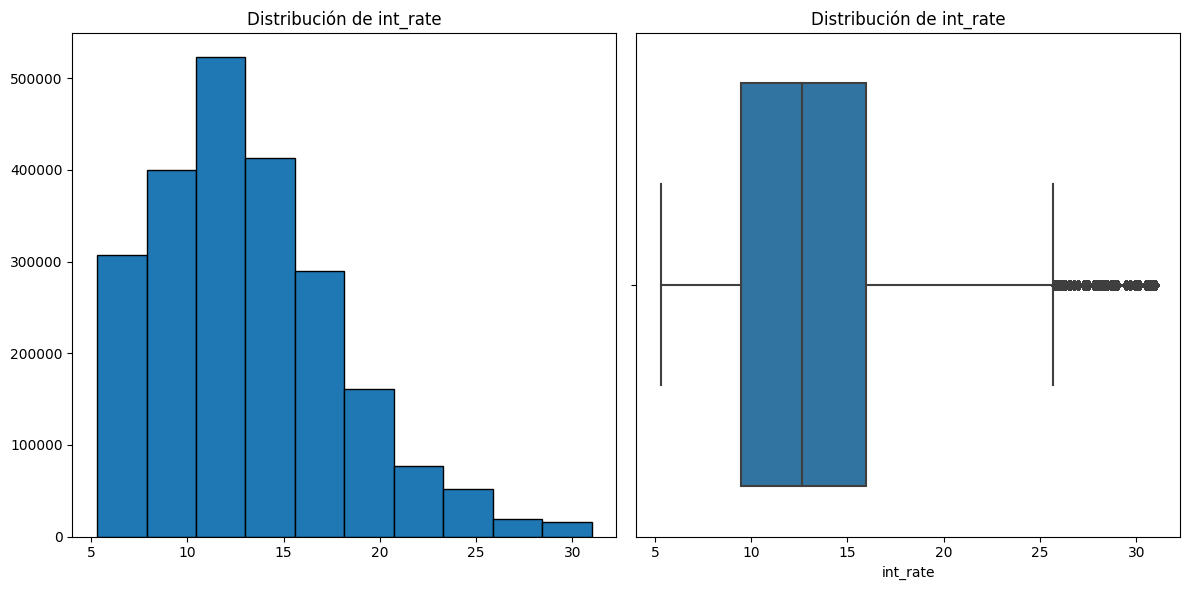


=== ANNUAL_INC ===
Skew: 494.44
Kurtosis:  439439.38
Coeficiente de Variación:  144.42 %


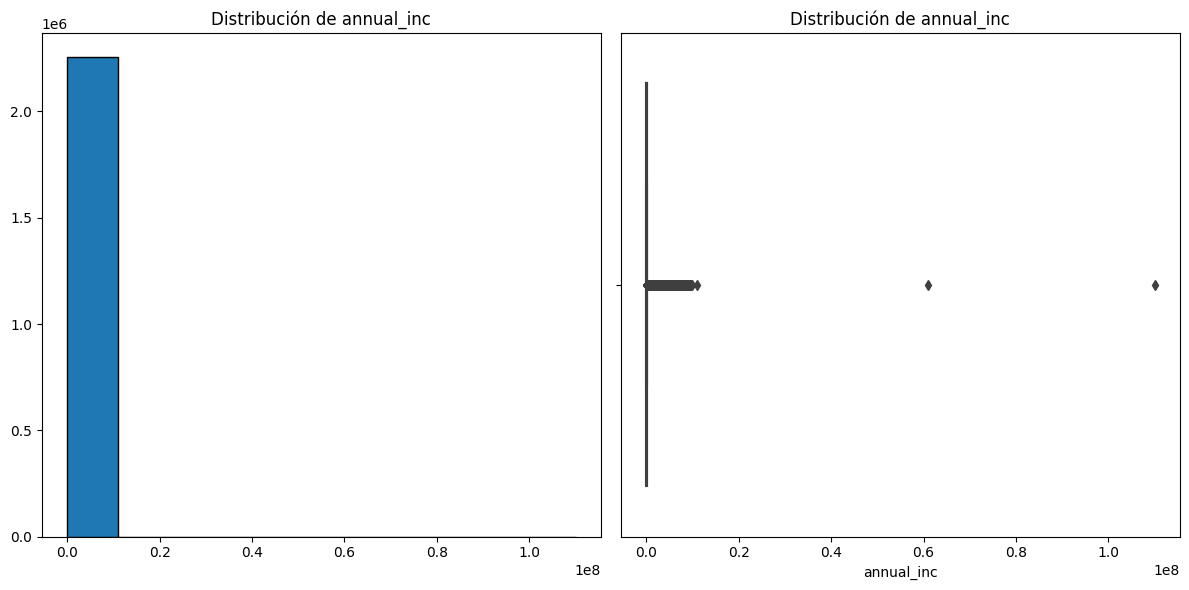


=== DTI ===
Skew: 29.1
Kurtosis:  1750.2
Coeficiente de Variación:  75.19 %


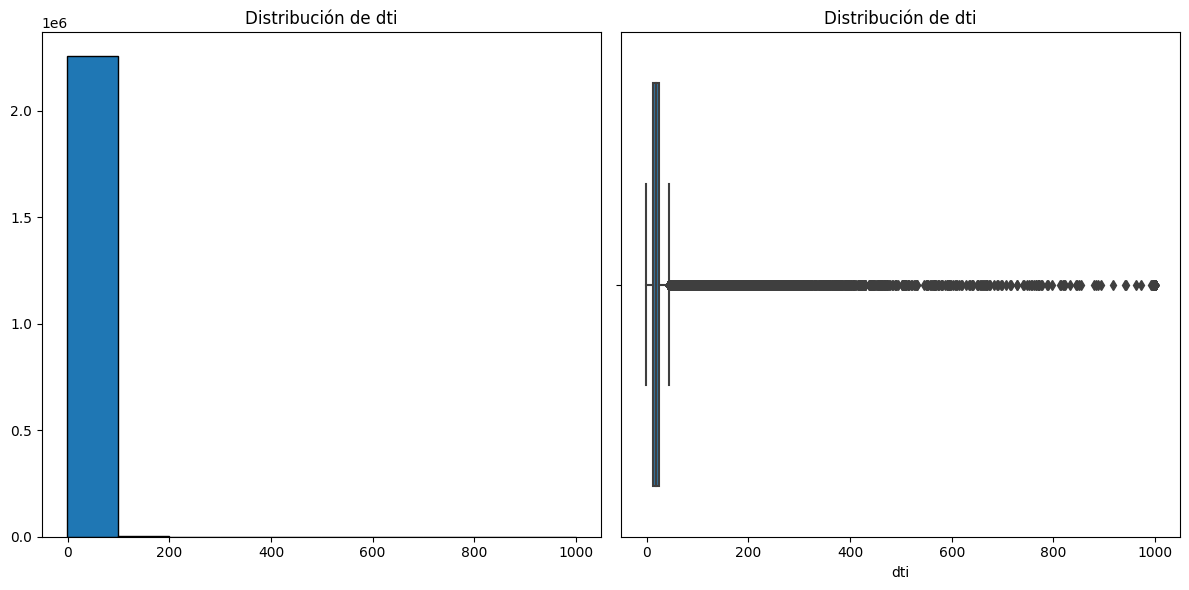


=== INQ_LAST_6MTHS ===
Skew: 2.07
Kurtosis:  9.57
Coeficiente de Variación:  153.53 %


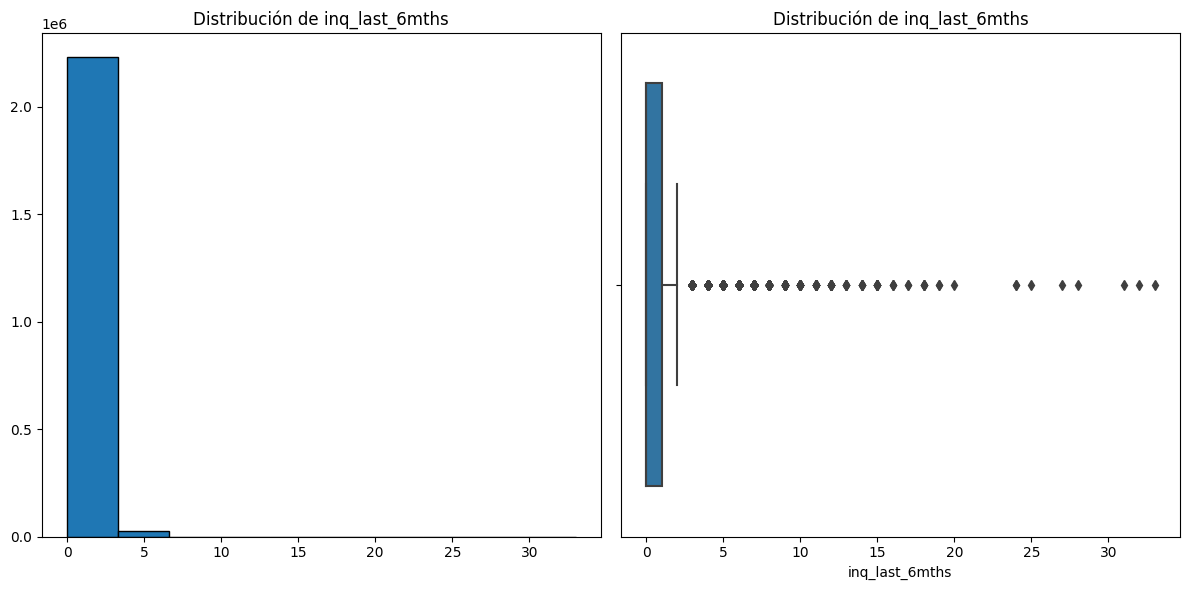


=== PUB_REC ===
Skew: 11.37
Kurtosis:  703.95
Coeficiente de Variación:  288.69 %


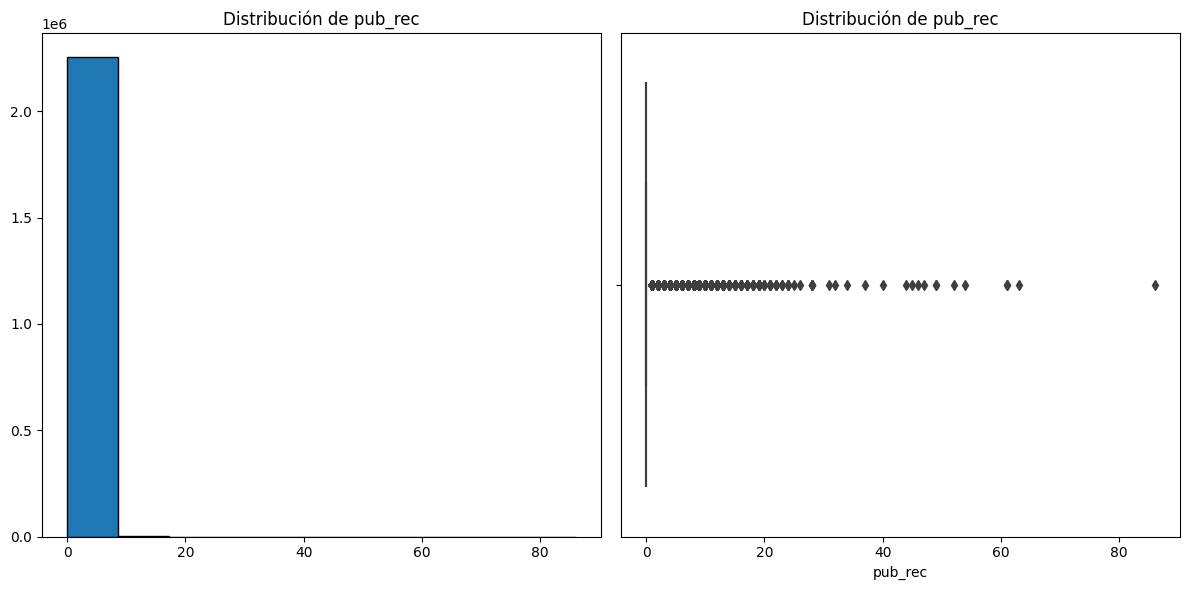


=== REVOL_BAL ===
Skew: 13.12
Kurtosis:  635.73
Coeficiente de Variación:  137.45 %


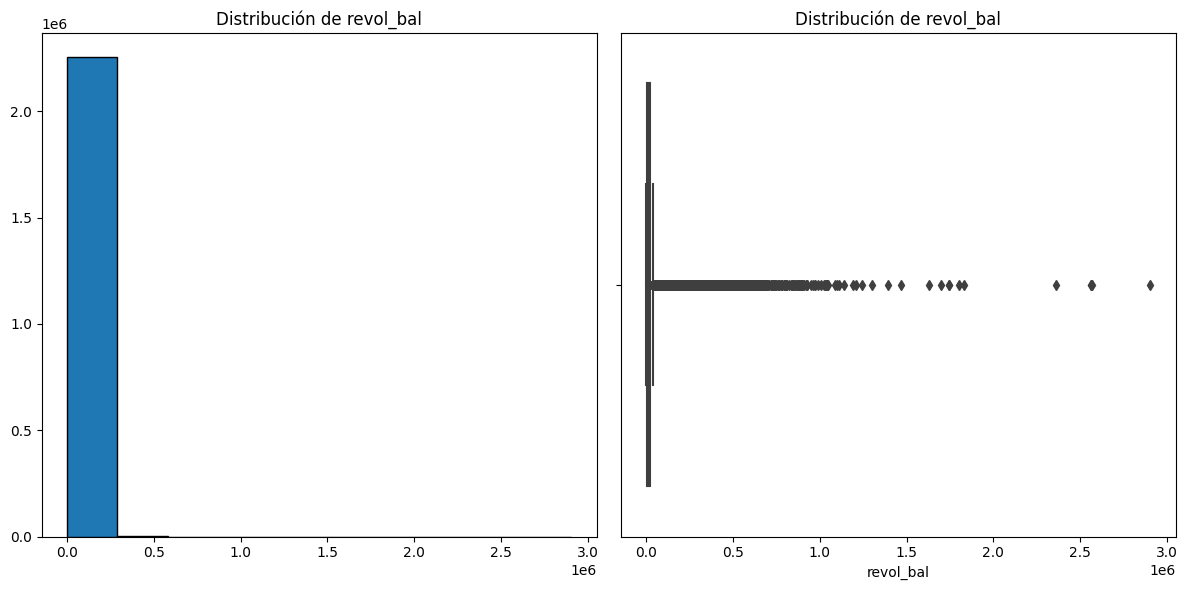


=== REVOL_UTIL ===
Skew: 0.01
Kurtosis:  -0.22
Coeficiente de Variación:  49.09 %


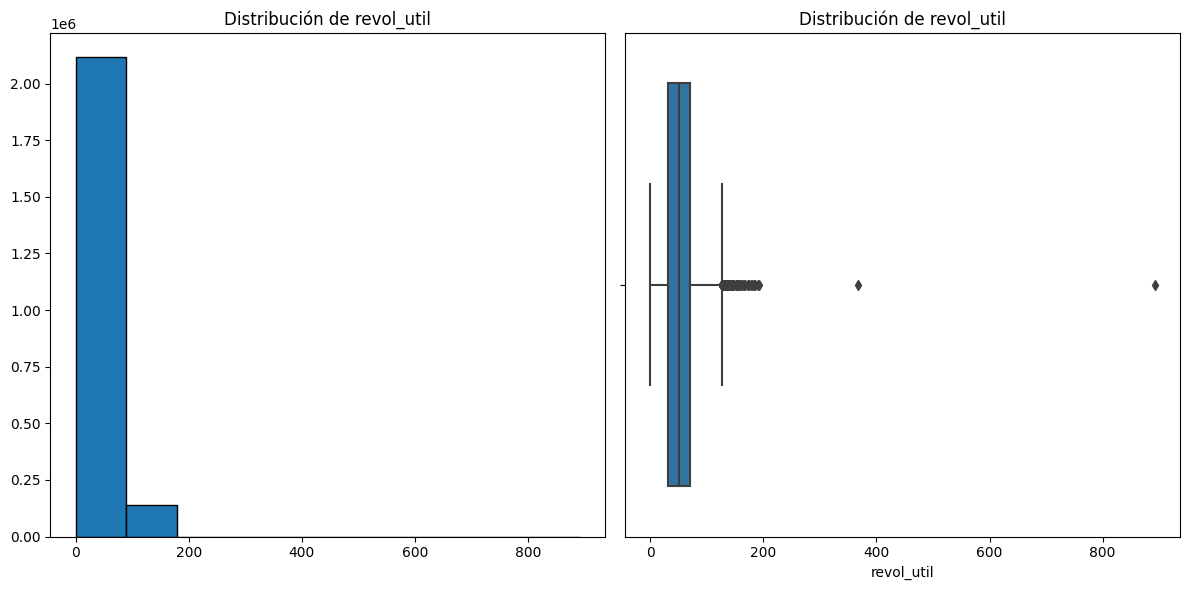

In [35]:
for col in variables_num:
    
    print(f"\n=== {col.upper()} ===")
    print('Skew:', round(df[col].skew(), 2))
    print('Kurtosis: ', round(df[col].kurtosis(), 2))
    coef_variacion = (df[col].std()/ df[col].mean() ) * 100
    print('Coeficiente de Variación: ', round(coef_variacion, 2), '%')
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    df[col].hist(grid=False, edgecolor = "black")
    plt.title(f'Distribución de {col}')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Distribución de {col}')
    plt.tight_layout()
    plt.show()

**1. FICO_RANGE_LOW/HIGH (Scores Crediticios)**
- **Asimetría (Skew ~1.19)**: Distribución moderadamente sesgada a la derecha
- **Curtosis (1.32)**: Distribución ligeramente más puntiaguda que la normal
- **CV (4.7%)**: Muy baja variabilidad relativa → valores muy consistentes
- **Interpretación**: Distribución relativamente normal con poca variabilidad, típica de scores crediticios que se agrupan en rangos predefinidos.

**2. INT_RATE (Tasa de Interés)**
- **Skew (0.77)**: Sesgo moderado a la derecha
- **Kurtosis (0.59)**: Distribución cercana a la normal
- **CV (36.9%)**: Variabilidad moderada
- **Interpretación**: Distribución bastante saludable, adecuada para modelado sin transformaciones mayores.

**3. ANNUAL_INC (Ingreso Anual)**
- **Skew (494.44)**: Sesgo extremadamente severo a la derecha
- **Kurtosis (439,439)**: Valores extremos masivos (outliers muy pronunciados)
- **CV (144%)**: Variabilidad extremadamente alta
- **Interpretación**: **Distribución altamente problemática**. Presencia de valores extremadamente altos que distorsionan completamente la distribución.

**4. DTI (Ratio Deuda-Ingreso)**
- **Skew (29.1)**: Sesgo severo a la derecha
- **Kurtosis (1,750)**: Presencia de outliers significativos
- **CV (75%)**: Alta variabilidad

**5. INQ_LAST_6MTHS (Consultas Crediticias)**
- **Skew (2.07)**: Sesgo moderado-alto a la derecha
- **CV (153%)**: Variabilidad muy alta
- **Interpretación**: La mayoría de personas tienen pocas consultas, pero algunos tienen muchas.

**6. PUB_REC (Registros Públicos)**
- **Skew (11.37)**: Sesgo muy severo
- **CV (288%)**: Variabilidad extremadamente alta
- **Interpretación**: La gran mayoría tiene 0 registros, pero los que tienen, tienen varios.

**7. REVOL_BAL (Balance Revolvente)**
- **Skew (13.12)**: Sesgo severo similar a DTI
- **Interpretación**: Presencia de outliers en balances de crédito.

**8. REVOL_UTIL (Utilización Revolvente)**
- **Skew (0.01)**: Casi perfectamente simétrica
- **Kurtosis (-0.22)**: Distribución ligeramente más plana que la normal
- **Interpretación**: **La distribución más normal de todas**, ideal para modelado.

#### **Tratamiento Valores Atípicos**

Para la identificación de valores atípicos en las variables númericas, se aplicó el método del rango intercuartílico (IQR).

In [37]:
for col in variables_num:
    
    print(f"\n=== {col.upper()} ===")
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"Número de outliers: {len(outliers)}")
    print(f"Porcentaje de outliers: {len(outliers)/len(df)*100:.2f}%")


=== FICO_RANGE_LOW ===
Número de outliers: 74650
Porcentaje de outliers: 3.31%

=== FICO_RANGE_HIGH ===
Número de outliers: 74650
Porcentaje de outliers: 3.31%

=== INT_RATE ===
Número de outliers: 40959
Porcentaje de outliers: 1.81%

=== ANNUAL_INC ===
Número de outliers: 109863
Porcentaje de outliers: 4.87%

=== DTI ===
Número de outliers: 21581
Porcentaje de outliers: 0.96%

=== INQ_LAST_6MTHS ===
Número de outliers: 94251
Porcentaje de outliers: 4.18%

=== PUB_REC ===
Número de outliers: 357618
Porcentaje de outliers: 15.84%

=== REVOL_BAL ===
Número de outliers: 136862
Porcentaje de outliers: 6.06%

=== REVOL_UTIL ===
Número de outliers: 114
Porcentaje de outliers: 0.01%


**Interpretación**

1. `FICO_RANGE_LOW` & `FICO_RANGE_HIGH`: FICO es una puntuación crediticia (rango entre 300 y 850). Todos los valores se encuentran en este rango, por tanto, a pesar de tener un 3.31% de outliers, son valores reales que aportan información y no afectan al modelo.

2. `INT_RATE`: Tasa de interés del préstamo. Presenta valores entre los rangos (5%–30%) valores comunes en lineas de crédito, todas las observaciones son reales y su capado podría hacernos perder información valiosa.

3. `ANNUAL_INC`: Ingreso anual declarado por el prestatario. Outliers altos (ej. ingresos millonarios) suelen ser reales pero distorsionan escalas. En este caso como tratamos con arboles de decisión, las escalas no son un problema, por tanto optaremos por no tratar estos outliers.

4. `DTI` (Debt-to-Income ratio): Mide la proporción entre los pagos mensuales de deuda y los ingresos del prestatario. Valores >100% indican que las deudas superan los ingresos, información que en algunos casos puede ser inconsistente. Para conservar información útil sobre la capacidad de pago sin distorsionar la distribución, aplicaremos winsorización al percentil 99.

5. `INQ_LAST_6MTHS`: Número de consultas de crédito en los últimos 6 meses. Valores altos (>10) pueden ser reales pero poco frecuentes. En este caso optaremos por la técnica de capado, ya que de esta manera se mejora la estabilidad del modelo al prevenir sobreajuste en divisiones con muy pocas muestras extremas.

6. `PUB_REC`: Registros públicos negativos (ej. quiebras, juicios). Tratamiento similar a `INQ_LAST_6MTHS`, valores altos (>10) pueden ser reales pero poco frecuentes.

7. `REVOL_BAL`: Saldo revolvente de tarjetas de crédito. Valores muy altos son reales pero desbalanceados, en este caso optaremos por winsorizar percentiles al 99%.

8. `REVOL_UTIL`: Utilización de crédito revolvente (porcentaje). Valores superiores a 100%, podrían ser errores o caso extremos de sobreutilización. En este caso optaremos por un capado al 200% para preservar instancias de sobreutilización que podrían explicar comportamientos de riesgo crediticio elevado y mantener la señal predictiva de patrones de uso agresivo del crédito revolvente.

In [41]:
p99_dti = df["dti"].quantile(0.99)
df["dti"] = df["dti"].clip(upper=p99_dti)

df["inq_last_6mths"] = df["inq_last_6mths"].clip(upper=10)

df["pub_rec"] = df["pub_rec"].clip(upper=10)

p99_revol_bal = df["revol_bal"].quantile(0.99)
df["revol_bal"] = df["revol_bal"].clip(upper=p99_revol_bal)

df["revol_util"] = df["revol_util"].clip(upper=200)

Se verifican los cambios realizados.

In [45]:
df[['dti','inq_last_6mths','pub_rec','revol_bal','revol_util']].describe().applymap(lambda x: f"{x:,.2f}")

,dti,inq_last_6mths,pub_rec,revol_bal,revol_util
count,"2,257,158.00","2,257,158.00","2,257,158.00","2,257,158.00","2,257,158.00"
mean,18.48,0.58,0.20,"15,951.72",50.34
std,8.83,0.88,0.54,"15,917.55",24.70
min,-1.00,0.00,0.00,0.00,0.00
25%,11.90,0.00,0.00,"5,960.00",31.50
50%,17.84,0.00,0.00,"11,332.00",50.30
75%,24.49,1.00,0.00,"20,252.00",69.40
max,42.71,10.00,10.00,"97,872.43",200.00


## **Análisis Bivariado**

El análisis bivariado es la segunda fase del análisis exploratorio de datos. Se enfoca en las relaciones entre dos variables para obtener datos estadísticos sobre sus influencias mutuas.

### **Variables Binarias vs default**

Se generan graficos de barras para analizar la relación entre el conjunto de variables binarias y el porcentaje de préstamos no exitosos o en mal estado con el fin de identificar qué variables binarias están asociadas a mayores proporciones de casos negativos en el conjunto de datos.

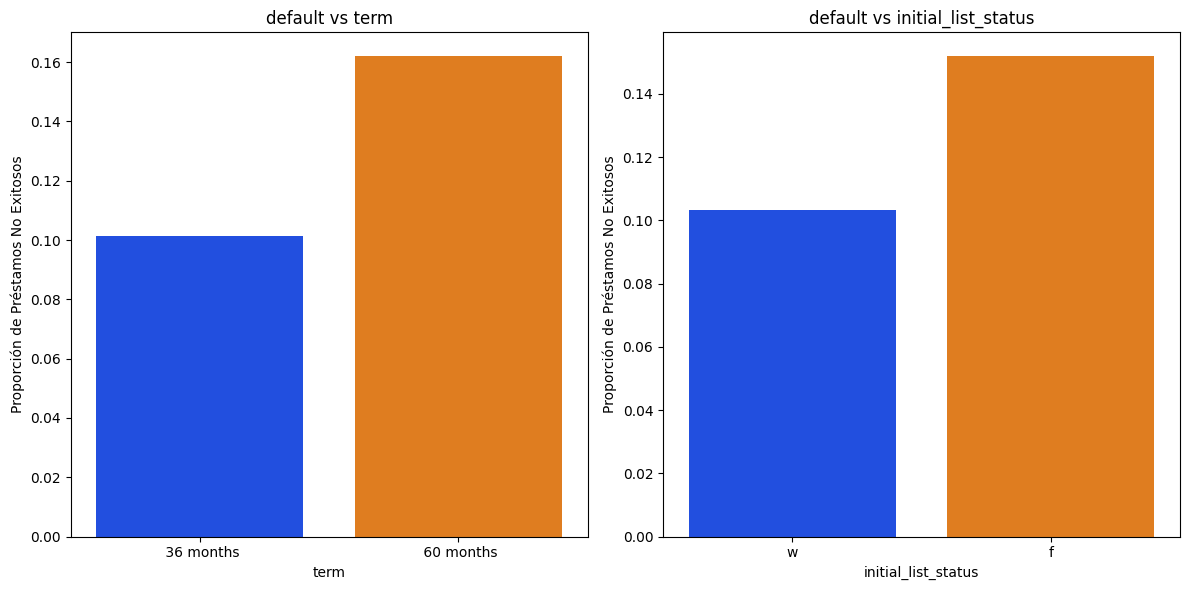

In [46]:
plt.figure(figsize=(12, 6)) 

for i, col in enumerate(var_binarias, 1):  
    plt.subplot(1, 2, i) 
    sns.barplot(
    x=col, 
    y='default', 
    data=df, 
    palette='bright',
    errorbar=None
    )
    plt.title(f'default vs {col}')
    plt.ylabel('Proporción de Préstamos No Exitosos')
plt.tight_layout()  
plt.show()

### **Variables Categóricas vs default**

Se generan graficos de barras para analizar la relación entre variables categóricas y el porcentaje de préstamos no exitosos o en mal estado en la población estudiada. Con el fin de identificar qué categorías dentro de cada variable presentan mayores proporciones de casos negativos en el conjunto de datos


=== EARLIEST_CR_LINE ===


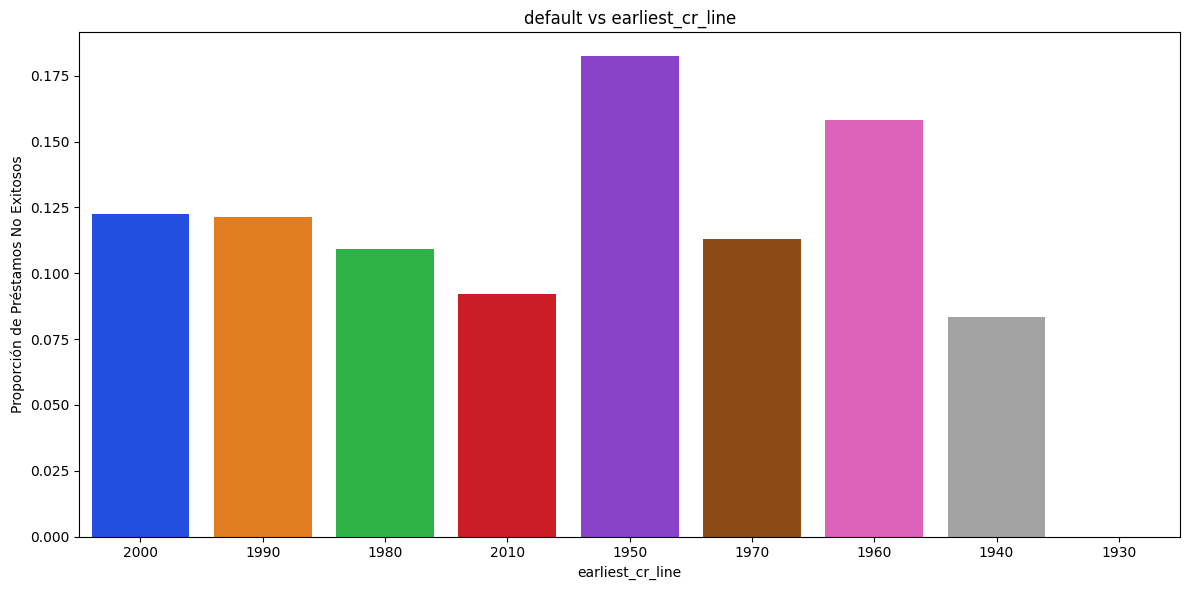


=== GRADE ===


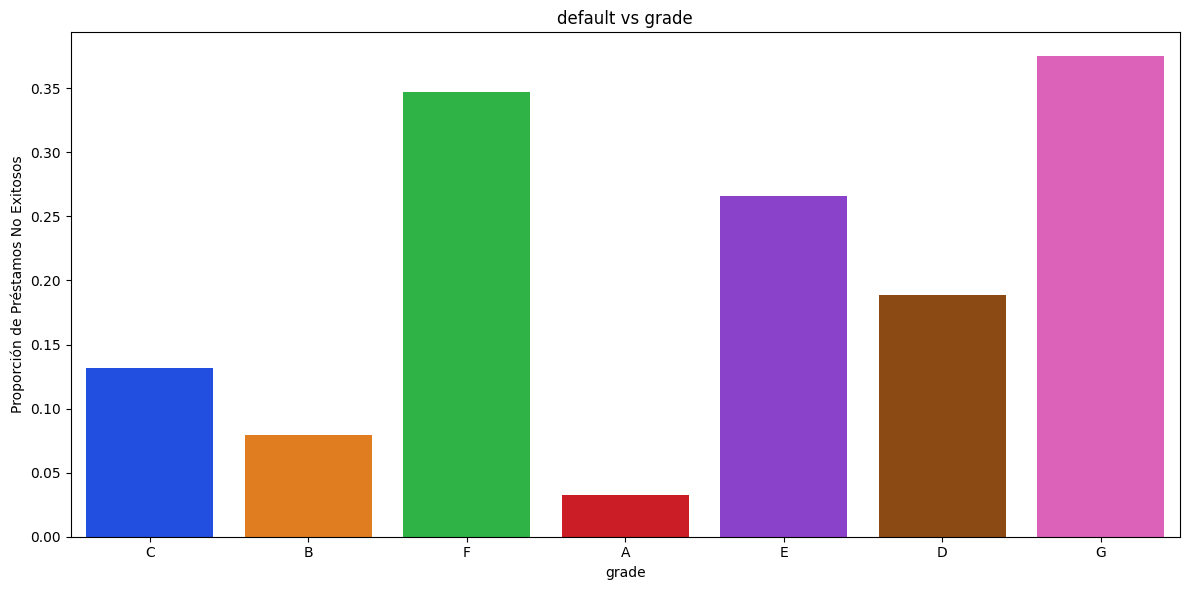


=== PURPOSE ===


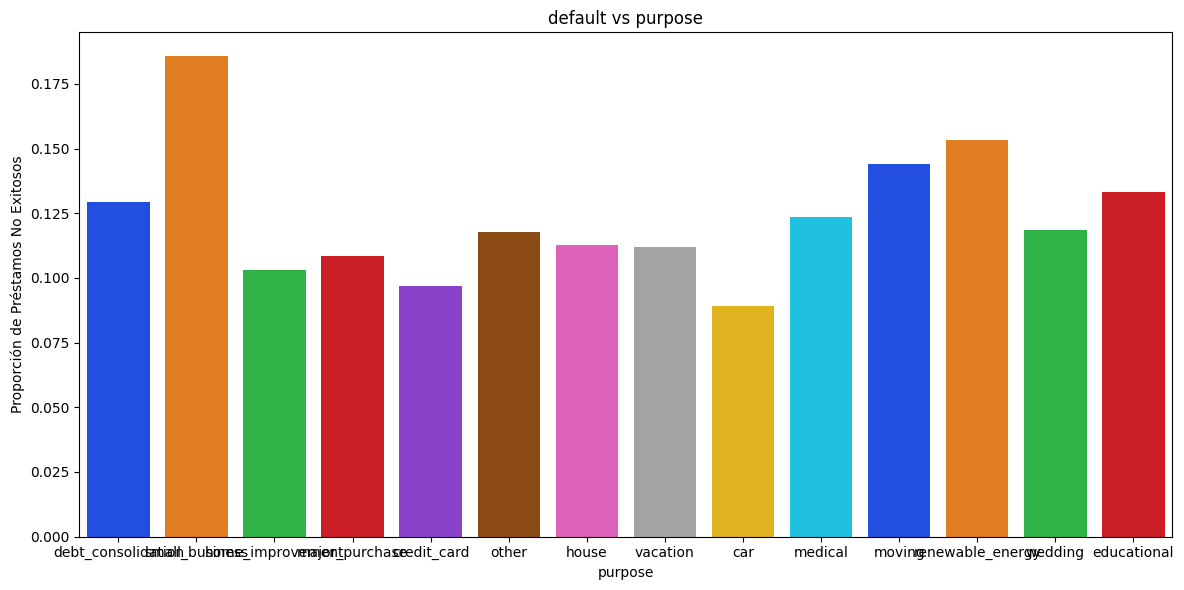


=== HOME_OWNERSHIP ===


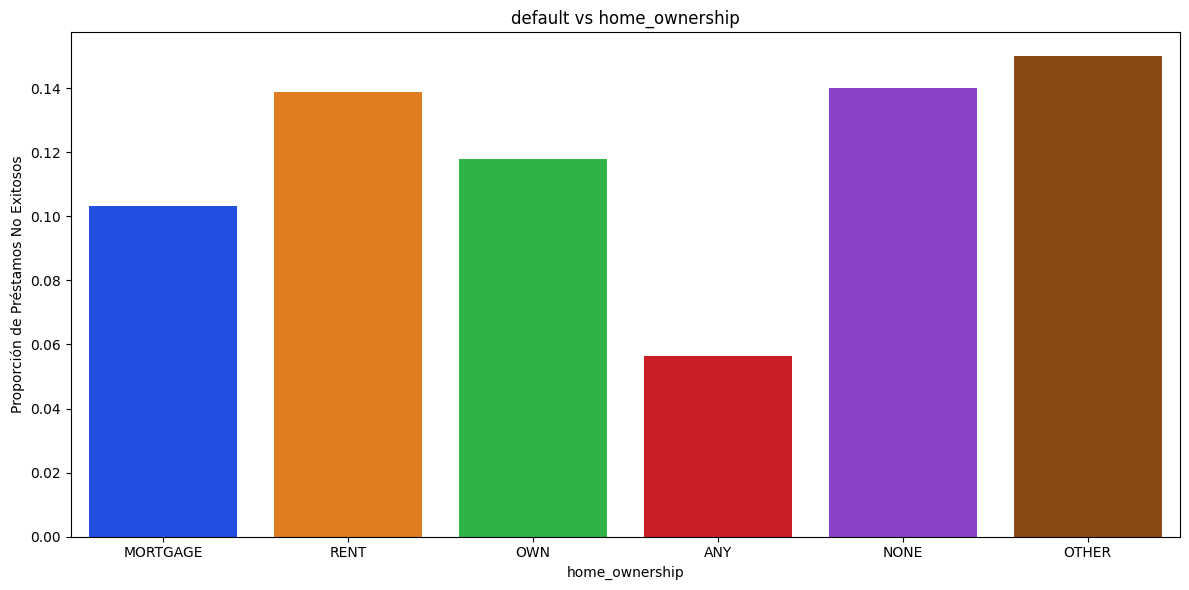


=== EMP_LENGTH ===


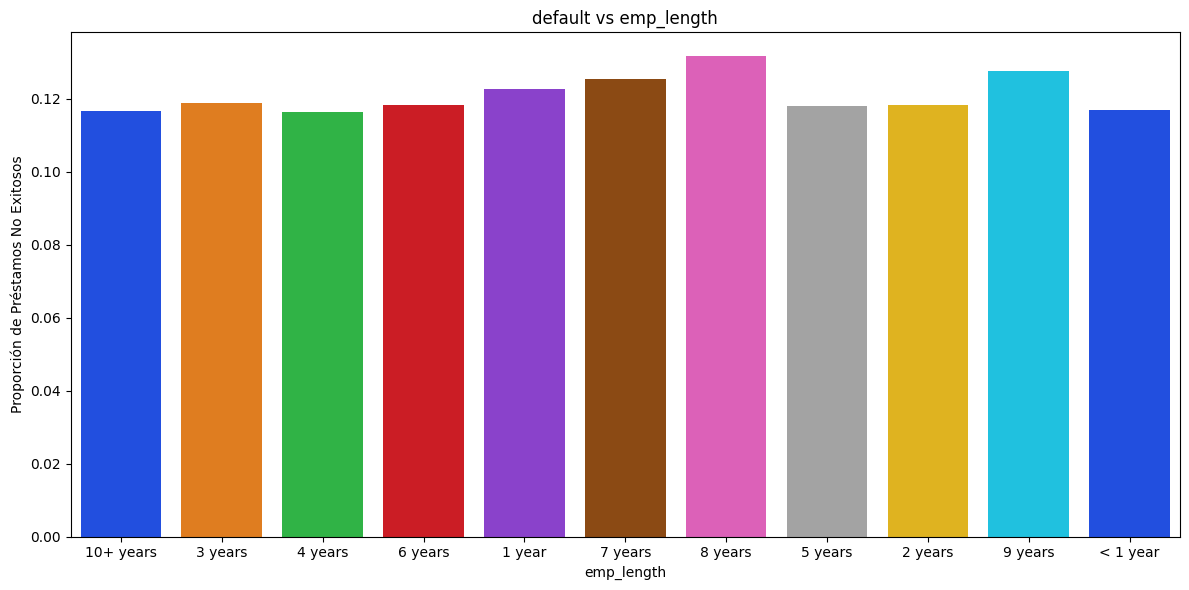


=== ADDR_STATE ===


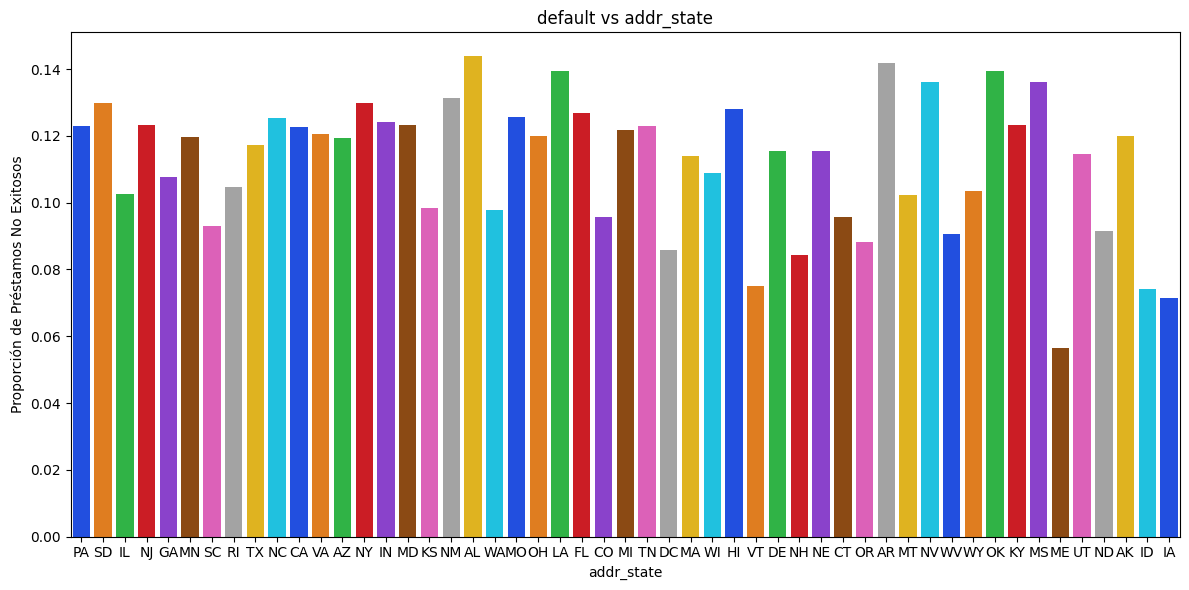


=== VERIFICATION_STATUS ===


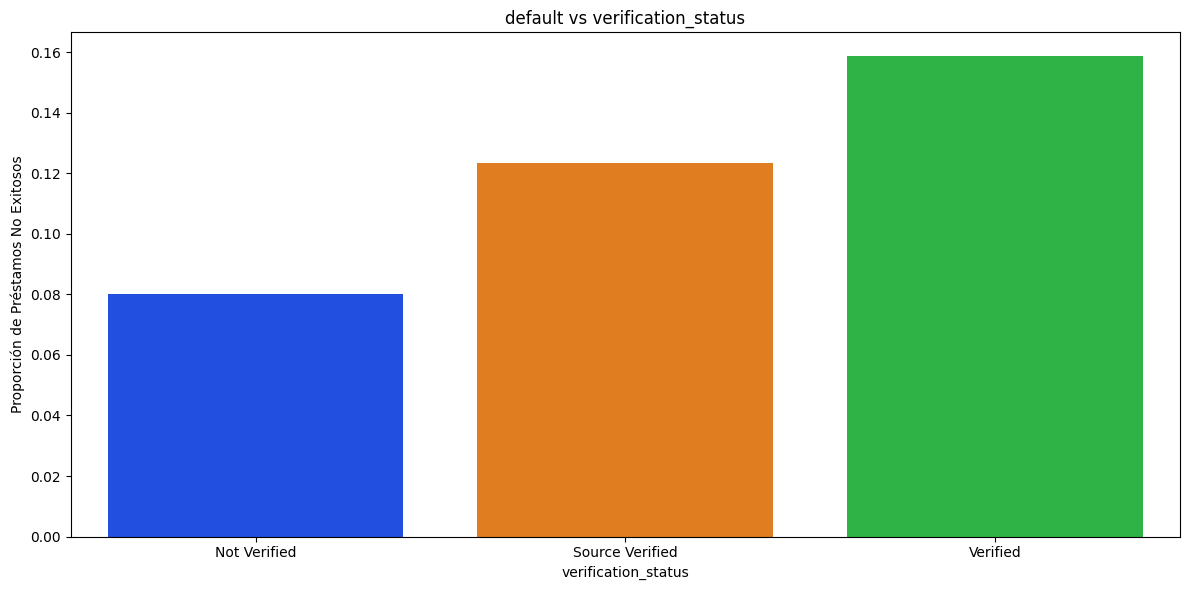

In [47]:
for col in variables_cat:
    
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=col, 
        y='default', 
        data=df, 
        palette='bright',
        errorbar=None  
    )

    plt.title(f'default vs {col}')
    plt.ylabel('Proporción de Préstamos No Exitosos')
    plt.tight_layout()
    plt.show()

### **Variables Númericas vs default**

Con el objetivo de identificar la relación entre las variables numéricas predictoras y la variable objetivo, se genera una serie de diagramas de caja (boxplots). Esta visualización permite comparar la distribución (mediana, rango intercuartílico) de cada variable numérica segmentada por las clases de dafault, facilitando la observación de diferencias significativas entre los grupos que podrían ser patrones predictivos clave.


=== FICO_RANGE_LOW ===


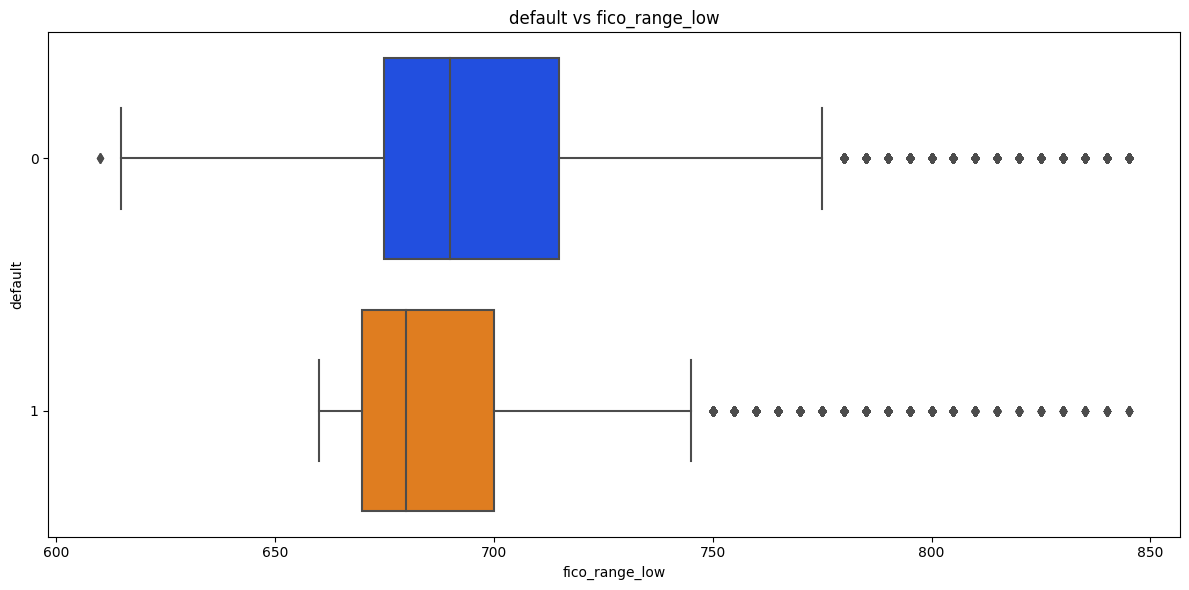


=== FICO_RANGE_HIGH ===


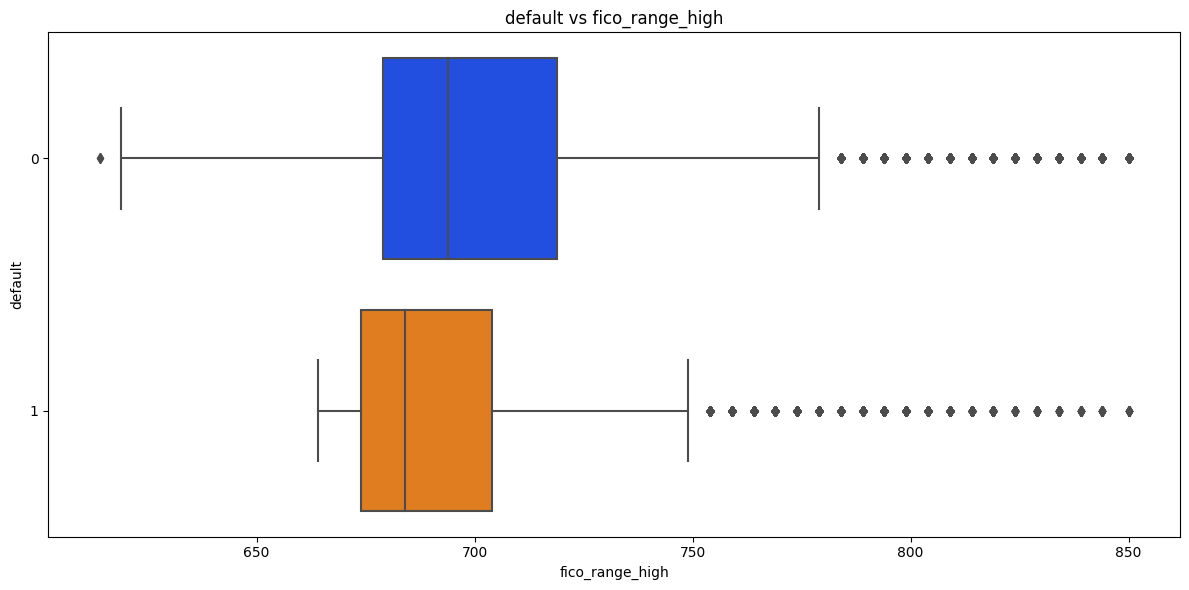


=== INT_RATE ===


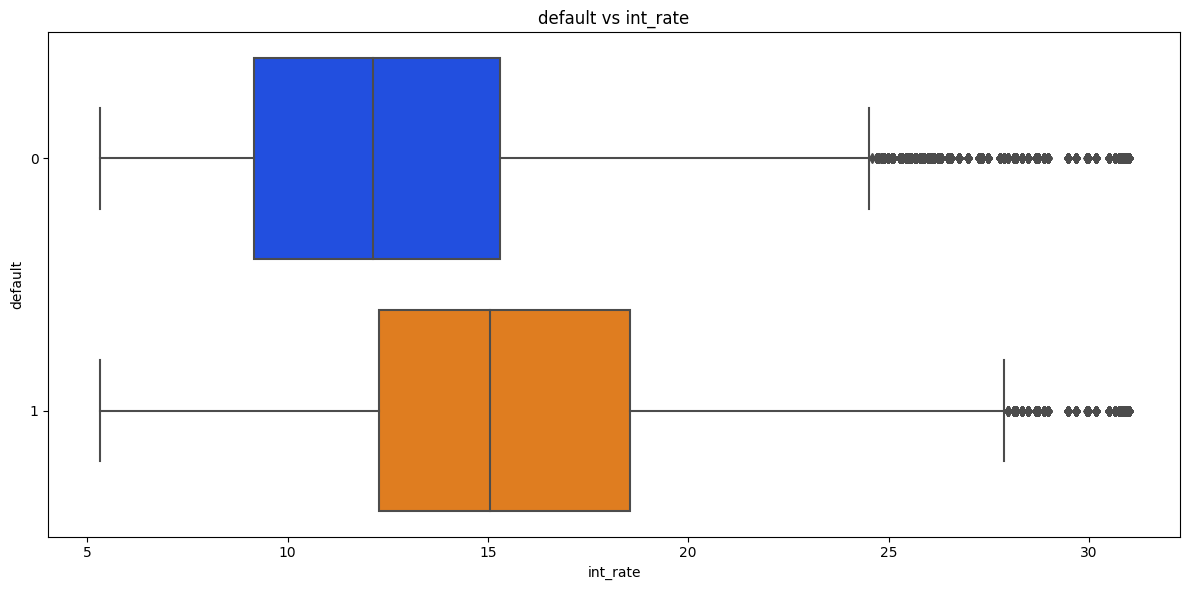


=== ANNUAL_INC ===


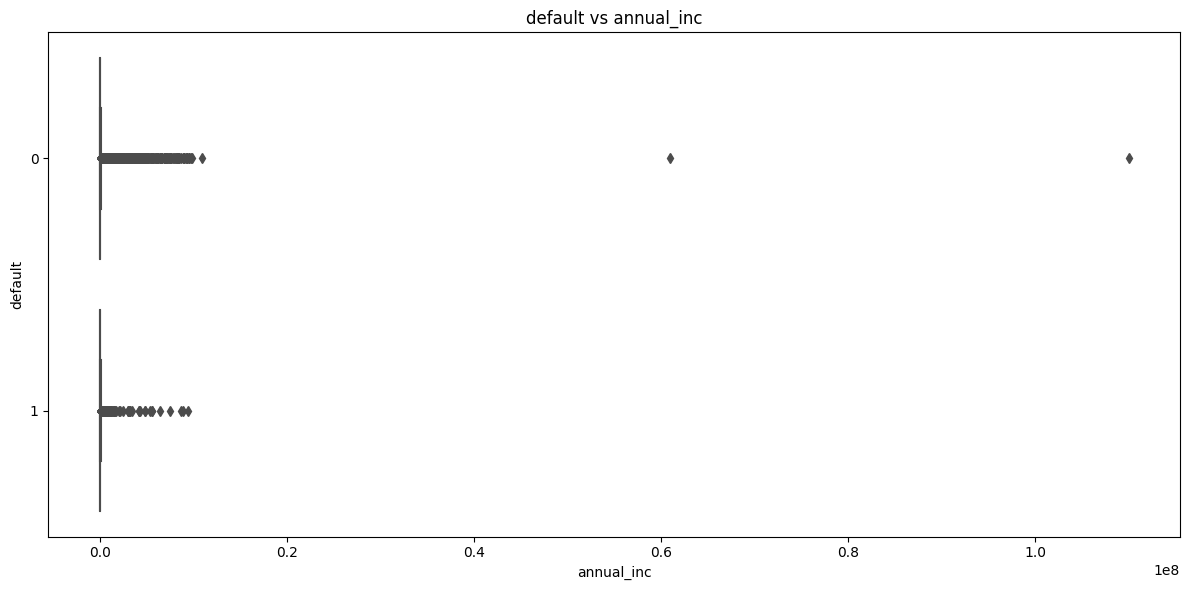


=== DTI ===


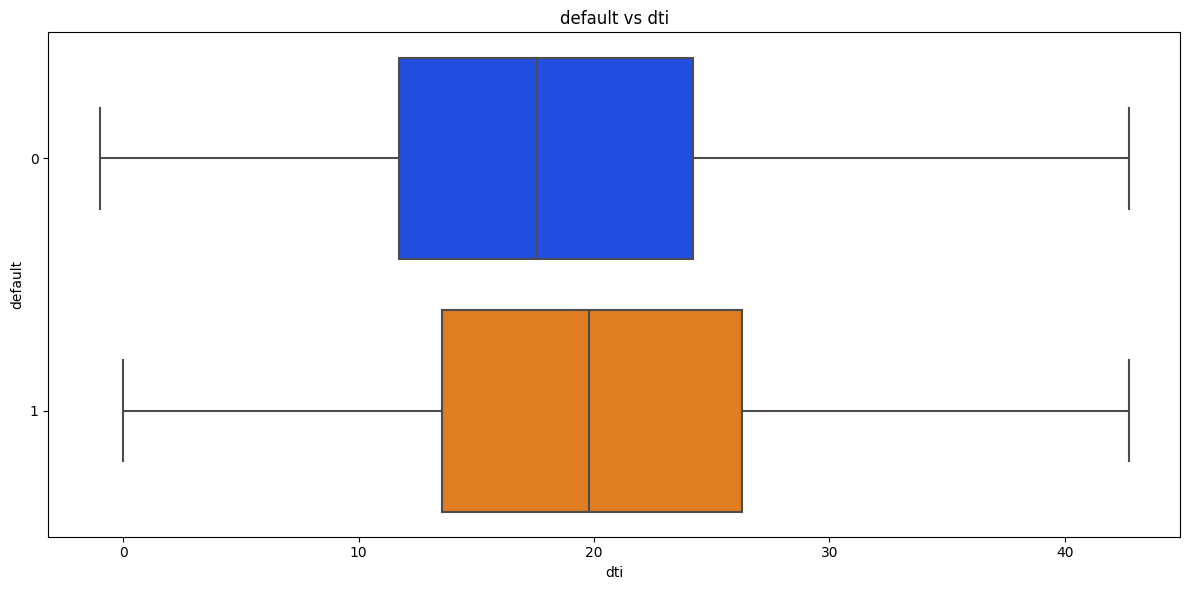


=== INQ_LAST_6MTHS ===


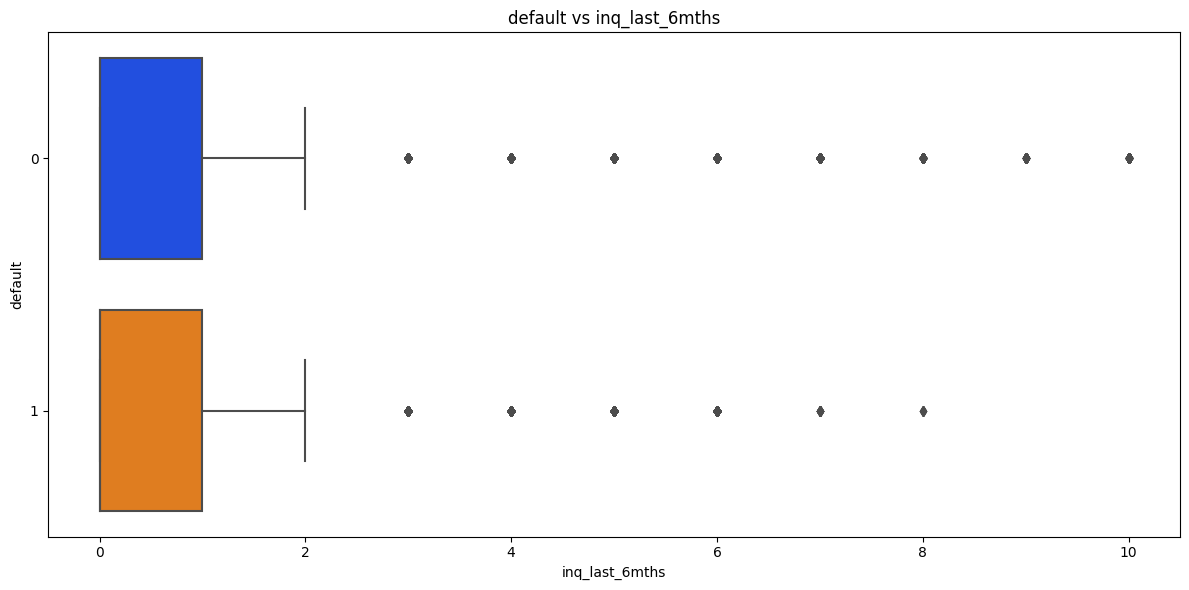


=== PUB_REC ===


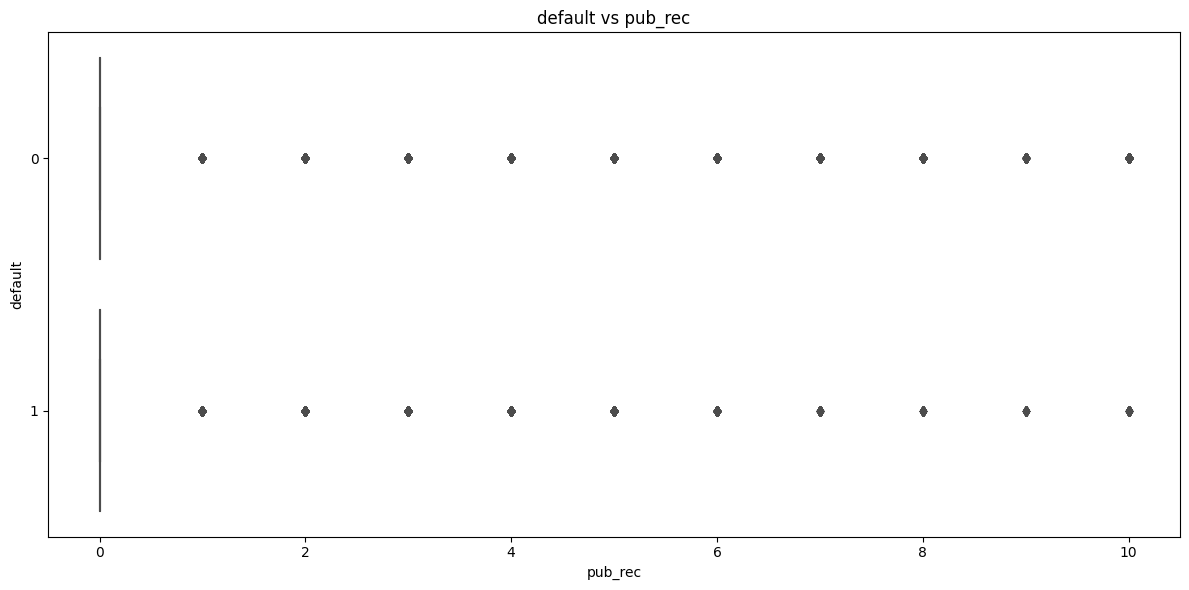


=== REVOL_BAL ===


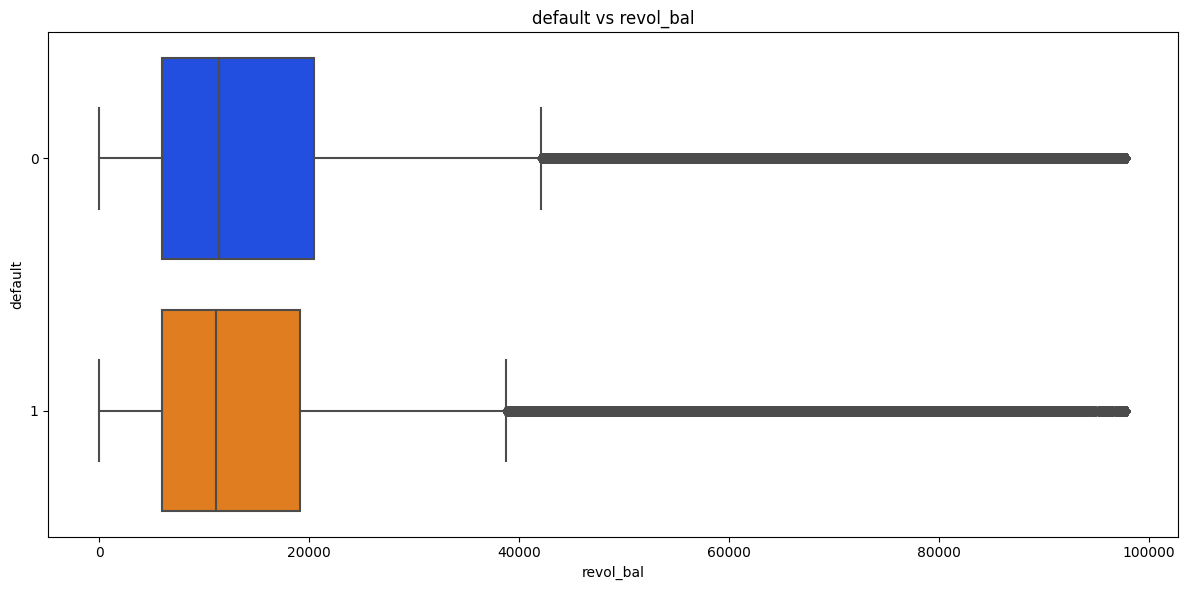


=== REVOL_UTIL ===


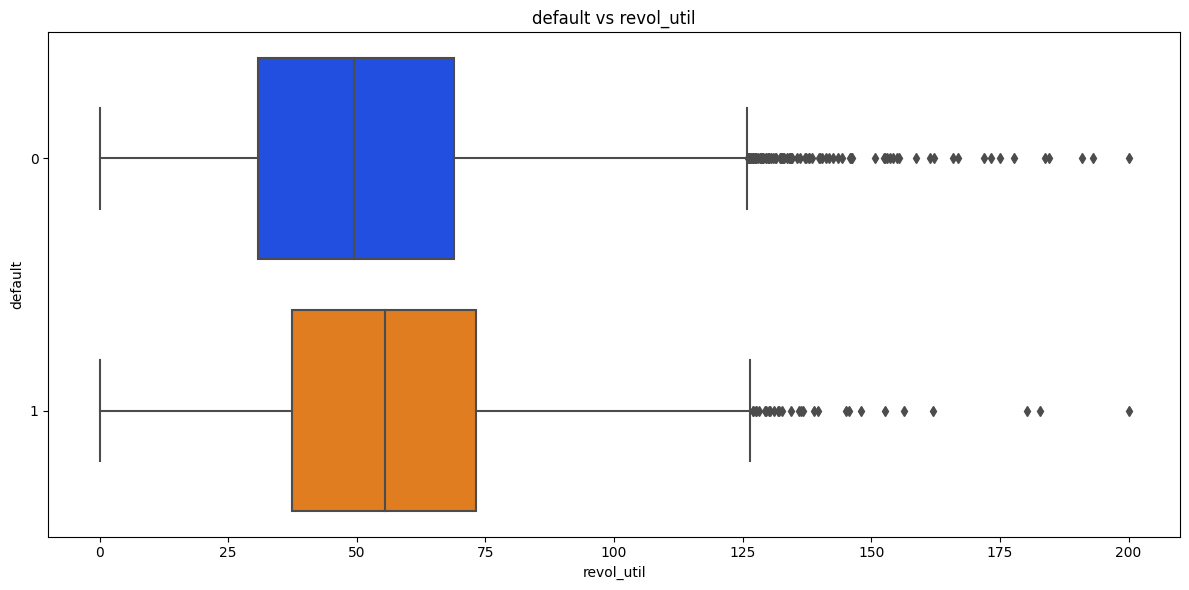

In [48]:
for col in variables_num:
    print(f"\n=== {col.upper()} ===")
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        x=col,          
        y='default',        
        data=df, 
        palette='bright', 
        orient='h'      
    )
    plt.title(f'default vs {col}') 
    plt.tight_layout()
    plt.show()

## **Análisis Multivariado**

Para identificar relaciones lineales entre las variables del Dataset, se generó una matriz de correlación mediante un heatmap. Este gráfico muestra el coeficiente de correlación de Pearson (rango: -1 a 1) entre cada par de variables númericas, utilizando una escala de colores (azul para correlaciones negativas, rojo para positivas). Los valores numéricos anotados permiten evaluar posibles dependencias entre variables.

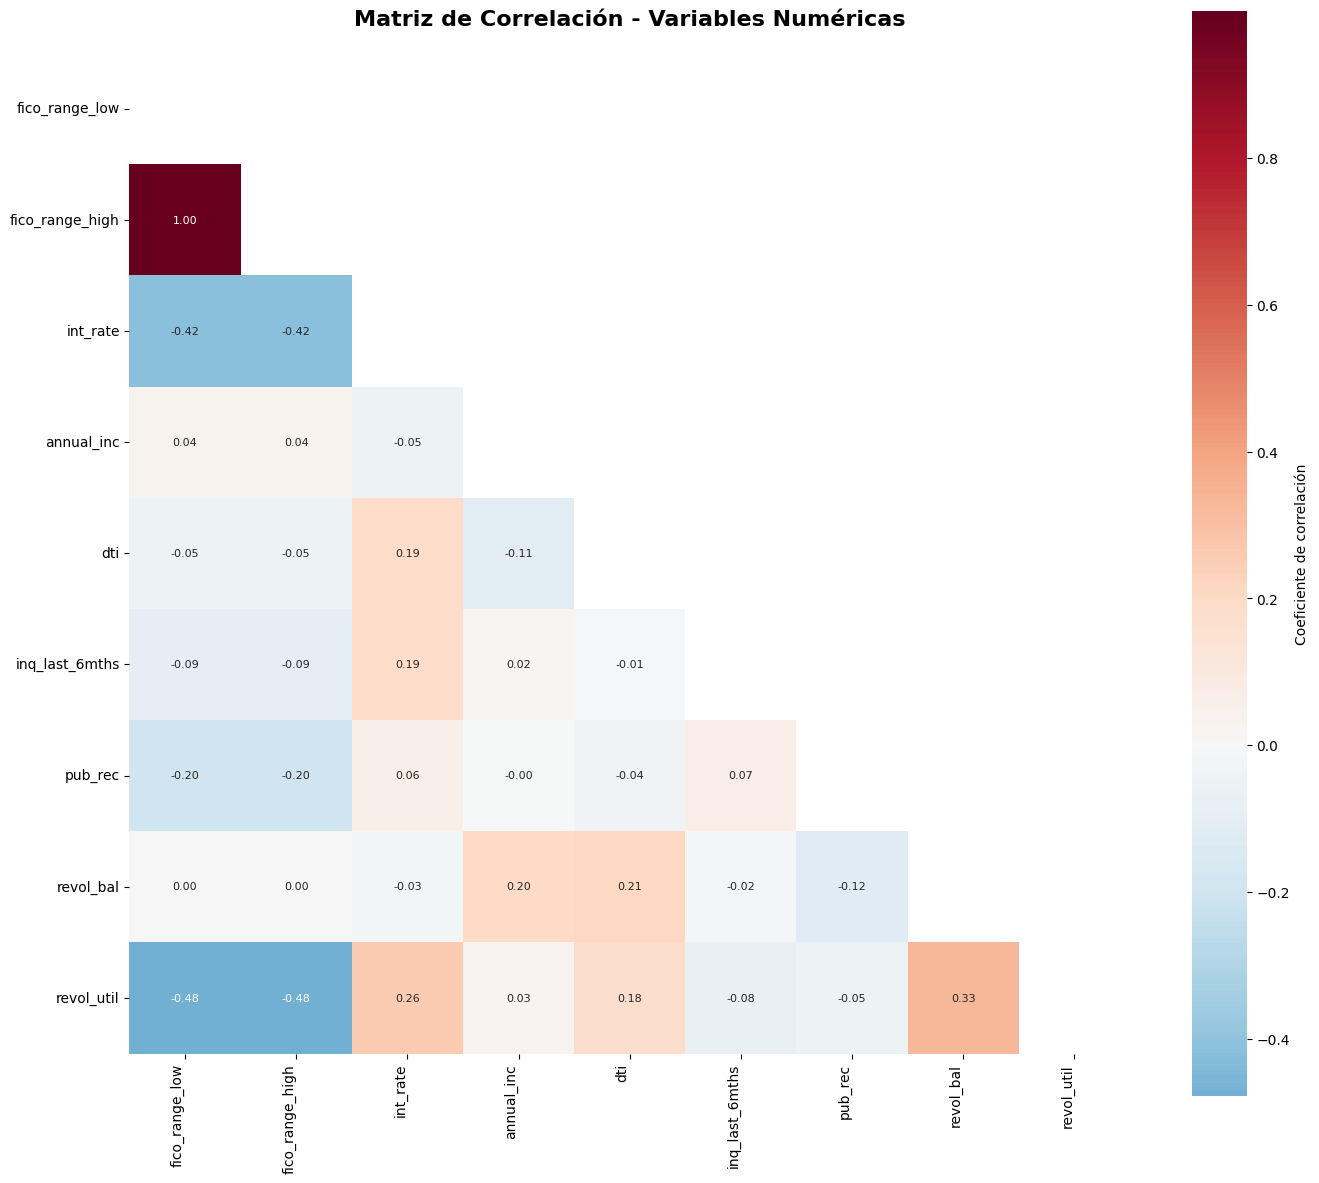

In [49]:
corr_matrix = df[variables_num].corr()

plt.figure(figsize=(14, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  

heatmap = sns.heatmap(corr_matrix, 
                      mask=mask,
                      annot=True, 
                      fmt='.2f', 
                      cmap='RdBu_r', 
                      center=0,
                      square=True, 
                      cbar_kws={"shrink": .8, "label": "Coeficiente de correlación"},
                      annot_kws={'size': 8})

plt.title('Matriz de Correlación - Variables Numéricas', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**1. Correlaciones más fuertes**

* **`fico_range_low` y `fico_range_high` (1.00)**
  → Tienen correlación perfecta, lo cual es lógico porque ambas representan los extremos inferior y superior del mismo rango de puntaje crediticio (son casi la misma variable).

* **`fico_range` vs `int_rate` (\~ -0.42)**
  → Hay una correlación **negativa moderada**: a mayor puntaje de crédito (`fico_range`), menor tasa de interés. Esto tiene sentido: mejores puntajes se asocian con préstamos más baratos.

* **`fico_range` vs `revol_util` (\~ -0.48)**
  → También hay correlación **negativa moderada**: quienes tienen mayor puntaje de crédito tienden a tener menor utilización de crédito. Es consistente con un buen comportamiento financiero.

* **`revol_bal` vs `revol_util` (\~ 0.33)**
  → Correlación **positiva débil a moderada**: a mayor saldo revolvente, mayor porcentaje de utilización de crédito, lo cual es esperable.

**2. Correlaciones bajas o casi nulas**

* **`annual_inc` con la mayoría de variables (\~ -0.11 a 0.20)**
  → Los ingresos anuales casi no se correlacionan con otras variables, lo cual indica que el nivel de ingreso no necesariamente se relaciona directamente con tasa de interés, FICO o comportamiento de crédito en este dataset.

* **`dti` con otras variables (\~ -0.04 a 0.21)**
  → Relación muy débil, lo que indica que el ratio deuda/ingreso no está fuertemente conectado con otras características aquí.

* **`inq_last_6mths` y `pub_rec`**
  → También muestran correlaciones muy bajas con todo, lo cual indica independencia casi total respecto al resto.

**3. Ideas principales del análisis**

* El **puntaje de crédito (FICO)** es la variable que más se relaciona con otras:

  * Negativamente con tasa de interés y utilización de crédito.
  * Esto refleja que los clientes con mejor historial tienen condiciones crediticias más favorables.

* La **tasa de interés** depende principalmente del puntaje FICO y, en menor medida, de la utilización del crédito.

* Variables como **ingresos, número de consultas recientes o registros públicos** no muestran un peso fuerte en las correlaciones, por lo que quizá influyen menos en las condiciones de crédito o lo hacen de manera no lineal.


## **Creación del Conjunto de Entrenamiento y Prueba**

Para evaluar de manera rigurosa y justa el desempeño final del modelo optimizado, es esencial probarlo en datos que no hayan sido vistos durante el proceso de ajuste de hiperparámetro. Por esta razón, se divide el dataset en subconjuntos de entrenamiento y prueba. El conjunto de entrenamiento (`X_train`, `y_train`) se utilizará para reentrenar el mejor modelo con todos los datos disponibles de entrenamiento, mientras que el conjunto de prueba (`X_test`, `y_test`) se reservará exclusivamente para la evaluación final, proporcionando una estimación no sesgada del rendimiento del modelo en datos nuevos.

Se divide las features (`X`) y la variable objetivo binaria (`y`), utilizando el parámetro `stratify` para garantizar que la proporción de las clases `default` se mantenga igual en ambos conjuntos, preservando así el balance original.

Un 20% de los datos se asigna para prueba en ambos casos, utilizando una semilla (`random_state=42`) para asegurar la reproducibilidad de la partición.

Ejecutamos la partición del dataset en matrices independientes: X conteniendo las variables independientes y y alojando la variable dependiente

In [50]:
from sklearn.model_selection import train_test_split

X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) 

## **Codificación de Variables**

Para adaptar las variables categóricas a los requerimientos de los algoritmos de machine learning, se implementa la técnica de One-Hot Encoding. Este proceso transforma cada categoría en una nueva variable binaria (0/1), preservando la ausencia de orden entre categorías y evitando la creación de jerarquías artificiales. La configuración del codificador incluye el manejo de categorías desconocidas en datos futuros (`handle_unknown="ignore"`), garantizando robustez durante la inferencia.

Con respecto a las variables numéricas, los algoritmos basados en árboles de decisión poseen inherentemente robustez ante diferencias de escala en las variables, ya que su mecanismo de división se fundamenta en umbrales relativos y no en distancias métricas o magnitudes absolutas. Esta característica elimina la necesidad de aplicar técnicas de escalado (como estandarización o normalización).

In [51]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(X_train[variables_cat])

X_train_encoded = encoder.transform(X_train[variables_cat])
X_test_encoded = encoder.transform(X_test[variables_cat])

X_train= pd.DataFrame(X_train_encoded, 
                                 columns=encoder.get_feature_names_out(variables_cat),
                                 index=X_train.index)

X_test = pd.DataFrame(X_test_encoded,
                                columns=encoder.get_feature_names_out(variables_cat),
                                index=X_test.index)

Se verifica la dimensionalidad del conjunto de entrenamiento, con el objetivo de confirmar la correcta estructuración de los datos antes de proceder al entrenamiento del modelo.

In [52]:
X_train.shape

(1805726, 101)

## **Tuning de hiperparámetros Scikit-learn**

Se implementa la optimización sistemática de hiperparámetros mediante `GridSearchCV`, utilizando una malla de búsqueda exhaustiva que explora metódicamente las combinaciones de parámetros más relevantes para el modelo, con el objetivo de identificar la configuración óptima que maximice el rendimiento predictivo y la generalización del algoritmo.

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10, 15],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42, 
        n_jobs=2, 
        class_weight='balanced'
    ),
    param_grid=param_grid,
    cv=5,                 
    scoring='roc_auc',    
    n_jobs=5,             
    verbose=1,            
    return_train_score=True
)

start = time.time()
grid_search.fit(X_train, y_train)
end = time.time()

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score (AUC):", grid_search.best_score_)
print("Mejor estimador:", grid_search.best_estimator_)
print(f"Tiempo total de GridSearchCV: {end - start:.2f} segundos")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Mejores parámetros: {'max_depth': 15, 'n_estimators': 100}
Mejor score (AUC): 0.6985339209738405
Mejor estimador: RandomForestClassifier(class_weight='balanced', max_depth=15, n_jobs=2,
                       random_state=42)
Tiempo total de GridSearchCV: 2463.12 segundos


El proceso de optimización ejecutó 45 entrenamientos completos (9 combinaciones de hiperparámetros × 5 folds de validación cruzada), requiriendo aproximadamente 41 minutos de procesamiento. La configuración óptima identificada utiliza una arquitectura de **100 árboles** con **profundidad máxima de 15 niveles**, indicando que el modelo se beneficia de una complejidad moderada-alta para capturar patrones en los datos.

El valor de **AUC-ROC de 0.6985** obtenido por el mejor estimador revela un desempeño moderado, situándose notablemente por encima de la aleatoriedad (0.5) pero aún por debajo del umbral de robustez (0.7-0.8). Cabe destacar que el modelo incorpora `class_weight='balanced'`, lo que evidencia un manejo proactivo del desbalance de clases observado en el dataset, aunque esto no fue suficiente para alcanzar un poder predictivo alto.

El tiempo de ejecución prolongado (2,463 segundos) refleja la densidad computacional del proceso, justificada por la búsqueda exhaustiva en el espacio de parámetros.

## **Modelado con scikit-learn y Métricas**

El modelo se reentrenó con la totalidad del conjunto de entrenamiento de clasificación (`X_train`, `y_train`) y se generaron tanto predicciones de clase (`predict`) como probabilidades (`predict_proba`) para el conjunto de prueba. El desempeño se evaluó mediante un conjunto exhaustivo de métricas y visualizaciones:

- **Métricas de Evaluación**:

    - **Accuracy**: Proporción general de predicciones correctas.

    - **Precision**: Capacidad del modelo de evitar falsos positivos.

    - **Recall**: Capacidad del modelo de evitar falsos negativos.

    - **F1-score**: Media armónica entre Precision y Recall, ideal para conjuntos balanceados.

- **Visualizaciones**:

    - **Matriz de Confusión**: Muestra de forma explícita los aciertos (diagonal) y los errores (falsos positivos y falsos negativos) del modelo.

    - **Curva ROC y AUC**: Evalúa la capacidad del modelo para distinguir entre clases a través de todos los posibles umbrales de clasificación. Un AUC de 0.5 representa un modelo aleatorio, mientras que 1.0 representa una separación perfecta.

Evaluación RandomForestClassifier
Accuracy: 0.6216794555990715
Precision: 0.1899906830982933
Recall: 0.6688159218814058
F1-score: 0.2959194610951246


<Figure size 1200x600 with 0 Axes>

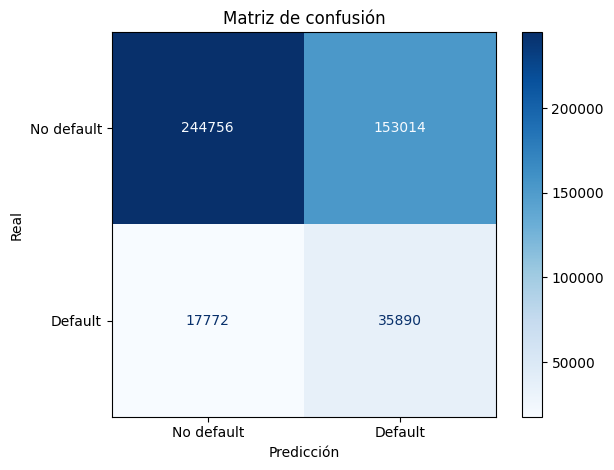

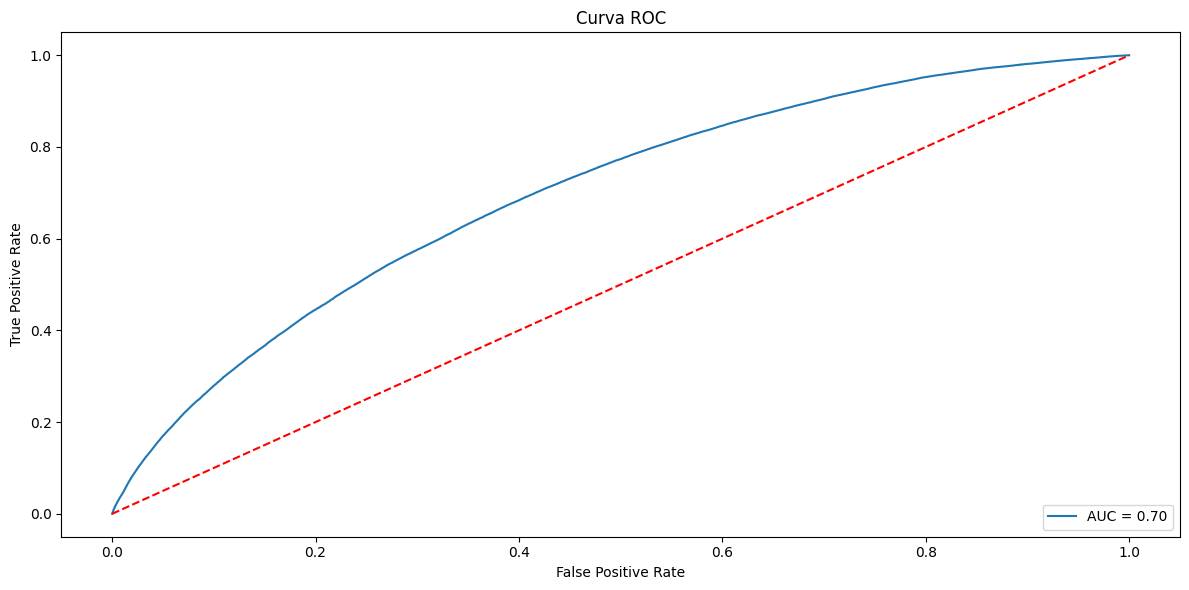

In [54]:
from sklearn.metrics import make_scorer, accuracy_score, f1_score, recall_score, precision_score, roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = grid_search.predict(X_test)
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluación RandomForestClassifier")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
plt.figure(figsize=(12, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                             display_labels=['No default', 'Default'])

fig, ax = plt.subplots()

disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión")

plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(12, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**1. Accuracy (Exactitud): 0.622**
- **Interpretación:** El modelo clasifica correctamente el 62.2% de las instancias
- **Limitación:** Métrica engañosa debido al desbalance de clases (88% vs 12%)
- **Significado real:** Predice mejor la clase mayoritaria (no default)

**2. Precision (Precisión): 0.190**
- **Interpretación:** Solo el **19%** de lo que el modelo identifica como "default" son realmente defaults
- **Problema grave:** Alta tasa de falsos positivos → de cada 10 préstamos clasificados como riesgosos, 8 son incorrectos
- **Implicación de negocio:** Aplicar medidas restrictivas basadas en estas predicciones generaría muchas restricciones innecesarias a clientes buenos

**3. Recall (Sensibilidad): 0.669**
- **Interpretación:** El modelo detecta correctamente el **66.9%** de todos los defaults reales
- **Aspecto positivo:** Capacidad aceptable para identificar casos de riesgo real
- **Brecha crítica:** **33.1%** de los defaults reales no son detectados (falsos negativos peligrosos)

**4. F1-Score: 0.296**
- **Interpretación:** Puntuación general muy baja que balancea Precision y Recall
- **Diagnóstico:** Confirma el desequilibrio severo entre las métricas

**Problema Principal:** **Compensación (trade-off) extrema entre Precision y Recall**
- **Estrategia actual:** El modelo está optimizado para detectar defaults (Recall aceptable) pero a costa de muchos falsos positivos (Precision muy baja)

**Conclusión:** El modelo actual tiene utilidad limitada. Detecta riesgos reales pero con un costo operativo inaceptable de falsas alarmas. 

## **Lime Scikit-learn y Feature Importance**  

La interpretabilidad de los modelos de machine learning es un pilar fundamental para garantizar transparencia, confianza y utilidad en aplicaciones del mundo real. En este contexto, se implementan dos metodologías complementarias: **LIME (Local Interpretable Model-agnostic Explanations)** y el análisis de **Feature Importance**.  

**LIME** se enfoca en explicaciones locales, es decir, desglosa predicciones individuales para mostrar cómo cada variable contribuyó a un resultado específico. Esta técnica genera perturbaciones alrededor de una instancia y entrena un modelo interpretable (como una regresión lineal) que aproxima el comportamiento del modelo complejo en esa región local. Al ser *model-agnostic*, LIME puede aplicarse a cualquier algoritmo (desde árboles de decisión hasta redes neuronales), proporcionando claridad sobre por qué el modelo tomó una decisión particular en casos concretos.  

Por otro lado, el **análisis de Feature Importance** ofrece una perspectiva global al cuantificar la contribución promedio de cada variable en las predicciones del modelo en todo el conjunto de datos. Métodos como *Gini Importance* (en árboles) o *permutation importance* permiten identificar las características con mayor influencia en el rendimiento general del modelo. Esta visión macro es crucial para priorizar variables en futuras iteraciones de feature engineering, depuración de datos o incluso para validar la alineación del modelo con el conocimiento de dominio.  

Juntos, estos enfoques forman un marco integral de interpretabilidad: **Feature Importance** destaca las variables globalmente relevantes, mientras que **LIME** contextualiza su impacto en predicciones individuales, permitiendo detectar sesgos, verificar consistencia lógica y comunicar resultados de manera comprensible.

### **Configuración del Explainer LIME**  

Para generar explicaciones locales e interpretables de las predicciones del modelo, se inicializa el explanador LIME para datos tabulares. Esta herramienta permite desglosar predicciones individuales identificando el aporte específico de cada variable en un instancia particular, facilitando la transparencia del modelo y la validación de sus criterios de decisión.  

In [55]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=["No Default", "Default"],
    mode="classification"
)

### **Análisis de Importancia de Variables Globales**  

Tras identificar el mejor modelo mediante la optimización de hiperparámetros, se extrae y visualiza la importancia global de las features. Este análisis cuantifica la contribución relativa de cada variable en las predicciones del modelo a nivel general, permitiendo priorizar características críticas y validar la coherencia del modelo con el dominio del problema.

In [56]:
best_model = grid_search.best_estimator_
pd.set_option('display.max_rows', None) 
pd.set_option('display.float_format', '{:.8f}'.format)
feature_importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print(importance_df)

                                 feature  importance
9                                grade_A  0.27783269
13                               grade_E  0.11310674
10                               grade_B  0.09981796
12                               grade_D  0.08137229
98      verification_status_Not Verified  0.07555326
14                               grade_F  0.06586037
11                               grade_C  0.04388083
100         verification_status_Verified  0.04212322
31               home_ownership_MORTGAGE  0.02118906
35                   home_ownership_RENT  0.02108243
15                               grade_G  0.01837794
99   verification_status_Source Verified  0.01368666
8                  earliest_cr_line_2010  0.01277710
17                   purpose_credit_card  0.00966497
18            purpose_debt_consolidation  0.00793490
6                  earliest_cr_line_1990  0.00476472
7                  earliest_cr_line_2000  0.00451769
37                  emp_length_10+ years  0.00

El análisis de importancia de variables revela patrones significativos sobre qué características tienen mayor influencia en las predicciones del modelo:

**La variable de mayor importancia se trata de `grade`**:

- `Grade A` (27.78%): La variable más influyente por un margen significativo.

- `Grade E` (11.31%), `Grade B` (9.98%), `Grade D` (8.13%): Siguen en importancia.

- `verification_status_Not Verified` (7.55%), `Grade F` (6.58%), ,`Grade C` (4.38%), 

### **Análisis de Error en Instancia Específica**  

Para comprender las causas subyacentes a una clasificación errónea del modelo, se selecciona y examina en profundidad una instancia particular donde la predicción no coincide con el valor real. Este análisis permite desglosar los factores que contribuyeron al error mediante la interpretación local con LIME, identificando qué variables influyeron decisivamente en la predicción incorrecta y facilitando la detección de patrones problemáticos en el comportamiento del modelo.

In [57]:
i = 125000
print("Predicción:", grid_search.best_estimator_.predict([X_test.iloc[i]]))
print("Real:", y_test.iloc[i])

exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=grid_search.best_estimator_.predict_proba
)

exp.show_in_notebook(show_table=True)

Predicción: [1]
Real: 0


**Caso Específico Analizado:**

- **Predicción del modelo:** 1 (Default - Riesgo de impago)
- **Valor real:** 0 (No Default - Pago normal)
- **Tipo de error:** **Falso Positivo** (clasificación conservadora)

**Análisis de Probabilidades:**
- **Probabilidad Default:** 57% (ligeramente por encima del threshold de 50%)
- **Probabilidad No Default:** 43%
- **Margen de error:** Muy estrecho (diferencia de 14 puntos porcentuales)

**Factores que Influyeron en la Predicción Errónea:**

**Variables que EMPUJARON hacia la clasificación como DEFAULT:**
1. **`grade_D` > 0.00** - Grado crediticio D (riesgo medio-alto)
2. **`verification_status_Not Verified`** - Ingresos no verificados
3. **`earliest_cr_line_2010`** - Historial crediticio relativamente reciente

**Variables que PUDIERON MITIGAR el riesgo (pero no fueron suficientes):**
- Ausencia de grados más riesgosos (F, G)
- Ausencia de grados más seguros (A, B)
- Ubicación geográfica no problemática (ME, VT)

**Razonamiento del modelo:**
- El perfil combina **grado crediticio moderado (D)** + **ingresos no verificados** + **historial crediticio joven**
- Esta combinación fue interpretada como **suficientemente riesgosa** para predecir default

**Posibles causas del error:**
1. **Sobregeneralización** del modelo con grados crediticios medios
2. **Excesivo peso** en el estatus de verificación de ingresos
3. **Falta de variables** compensatorias (ej: alto ingreso, bajo DTI)

**Conclusión:** El error muestra un patrón de **conservadurismo excesivo** del modelo, donde características de riesgo moderado son interpretadas como determinantes, ignorando posiblemente factores compensatorios no capturados en las features disponibles.

## **Implementación en PySpark**

PySpark es el framework de Apache Spark para Python, diseñado para procesamiento distribuido de grandes volúmenes de datos. A diferencia de bibliotecas como Pandas o Scikit-learn, que operan en un solo nodo, PySpark permite ejecutar operaciones en clústeres, facilitando el manejo de datasets que exceden la capacidad de la memoria de una máquina individual. Su arquitectura distribuida lo hace ideal para proyectos de big data, machine learning escalable y ETL en entornos productivos.  

En este contexto, se realiza una modificación crítica en el nombre de la variable objetivo: se renombra `default` como `label`. Este cambio no es arbitrario, sino que se alinea con las convenciones estructurales de PySpark, específicamente con los requerimientos de la biblioteca MLlib (Machine Learning Library). En MLlib, los algoritmos de aprendizaje supervisado esperan que la variable dependiente se denomine `label` y las características independientes se agrupen en una sola columna llamada `features`.  

La estandarización del nombre previene errores durante la fase de modelado, ya que métodos como `LinearRegression`, `RandomForestClassifier`, o `CrossValidator` buscan automáticamente una columna named `label` para definir el target. Además, esta convención mejora la legibilidad del código y garantiza compatibilidad con herramientas integradas de PySpark, como `Pipeline` y `CrossValidator`, que dependen de esta nomenclatura para operar correctamente.  

Este paso refleja la adaptación necesaria para migrar de un entorno de análisis local (Pandas/Scikit-learn) a un entorno distribuido (PySpark), asegurando que el flujo de trabajo sea escalable, eficiente y alineado con las mejores prácticas de la industria en procesamiento de big data.

In [58]:
df = df.rename(columns={"default": "label"})

### **Creación de la Sesión Spark y Carga del Dataset**  

Se inicia una sesión de Apache Spark configurada para ejecución local con 8 GB de memoria asignada, optimizando así el manejo de recursos para el procesamiento distribuido. Posteriormente, se convierte el DataFrame de pandas al formato Parquet, un formato columnar eficiente que garantiza compresión y rendimiento en entornos distribuidos. Este archivo se carga como un DataFrame de PySpark, aprovechando las capacidades de escalabilidad y procesamiento paralelo del framework. Finalmente, se verifica la integridad de la carga mediante la visualización de las primeras filas del dataset, asegurando que la estructura y los datos se hayan transferido correctamente al entorno Spark.

In [59]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CreditDefaultRF") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

df.to_parquet("df_clean.parquet", index=False, engine='pyarrow')

df_pyspark = spark.read.parquet("df_clean.parquet")

print("Primeras Filas del Dataset:")
df_pyspark.show(5)


Primeras Filas del Dataset:
+--------------+---------------+--------+----------+-----+----------------+-----+------------------+----------+--------------+----------+----------+-------------------+--------------+-------+---------+----------+-------------------+-----+
|fico_range_low|fico_range_high|int_rate|annual_inc|  dti|earliest_cr_line|grade|           purpose|      term|home_ownership|emp_length|addr_state|verification_status|inq_last_6mths|pub_rec|revol_bal|revol_util|initial_list_status|label|
+--------------+---------------+--------+----------+-----+----------------+-----+------------------+----------+--------------+----------+----------+-------------------+--------------+-------+---------+----------+-------------------+-----+
|         675.0|          679.0|   13.99|   55000.0| 5.91|            2000|    C|debt_consolidation| 36 months|      MORTGAGE| 10+ years|        PA|       Not Verified|           1.0|    0.0|   2765.0|      29.7|                  w|    0|
|         715.0|

### **Seleccionamos las variables usadas con Scikit-Learn**

In [60]:
variables_cat = ['earliest_cr_line',
 'grade',
 'purpose',
 'home_ownership',
 'emp_length',
 'addr_state',
 'verification_status']

variables_num = ['fico_range_low',
 'fico_range_high',
 'int_rate',
 'annual_inc',
 'dti',
 'inq_last_6mths',
 'pub_rec',
 'revol_bal',
 'revol_util']

var_binarias = ['term', 'initial_list_status']

### **División Estratificada del Conjunto de Datos**  

Para garantizar una evaluación rigurosa y reproducible del modelo, se divide el dataset en subconjuntos de entrenamiento y prueba. Esta partición se realiza de manera estratificada, preservando la proporción original de la variable objetivo en ambos conjuntos y evitando así desbalances que pudieran sesgar la evaluación. El 80% de los datos se destina al entrenamiento, mientras que el 20% restante se reserva exclusivamente para la prueba final, asegurando que el modelo sea evaluado con datos nunca vistos durante su desarrollo. La semilla (`seed=42`) garantiza la reproducibilidad de la partición en futuras ejecuciones.

In [61]:
train_data, test_data = df_pyspark.randomSplit([0.8, 0.2], seed=42)

print(f"Tamaño train: {train_data.count()}, test: {test_data.count()}")

Tamaño train: 1805772, test: 451386


### **Validación de la Distribución de Clases**  

Tras la división del dataset, se verifica que la proporción de la variable objetivo se haya preservado correctamente en ambos conjuntos (entrenamiento y prueba). Este paso es crítico para asegurar que el modelo se entrene y evalúe con una representación equilibrada de las clases, evitando sesgos que pudieran afectar su capacidad predictiva.

In [62]:
print("Distribución en train:")
train_dist = train_data.groupBy("label").count().toPandas()
print(train_dist)

print("\nDistribución en test:")
test_dist = test_data.groupBy("label").count().toPandas()  
print(test_dist)

Distribución en train:
   label    count
0      0  1591415
1      1   214357

Distribución en test:
   label   count
0      0  397435
1      1   53951


### **Preprocesamiento de Variables Categóricas y Numéricas**  

Para adaptar el dataset a los requerimientos de los algoritmos de machine learning en PySpark, se ejecuta un pipeline de transformación que incluye: la indexación de variables categóricas y binarias mediante `StringIndexer`, la codificación one-hot de estas categorías para evitar ordinalidad artificial, y la consolidación de todas las features en un único vector de características utilizando `VectorAssembler`. Este proceso garantiza que los datos estén estructurados en el formato adecuado para su consumo por los modelos de MLlib, preservando la relación entre variables y manteniendo la integridad de la información original.

In [63]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

for cat in variables_cat + var_binarias:
    indexer = StringIndexer(inputCol=cat, outputCol=cat+"_idx", handleInvalid="keep")
    indexer_model = indexer.fit(train_data)
    train_data = indexer_model.transform(train_data)
    test_data = indexer_model.transform(test_data)  

for cat in variables_cat + var_binarias:
    encoder = OneHotEncoder(inputCol=cat+"_idx", outputCol=cat+"_ohe")
    encoder_model = encoder.fit(train_data)
    train_data = encoder_model.transform(train_data)
    test_data = encoder_model.transform(test_data)


feature_cols = [c+"_ohe" for c in variables_cat + var_binarias] + variables_num
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
train_data = assembler.transform(train_data)
test_data = assembler.transform(test_data)


### **Tuning de Hiperparámetros en PySpark**  

Para optimizar el rendimiento del modelo de Random Forest, se implementa un proceso de búsqueda manual de hiperparámetros evaluando combinaciones de `numTrees` (número de árboles) y `maxDepth` (profundidad máxima). Este enfoque permite explorar el trade-off entre complejidad del modelo y capacidad de generalización. Cada configuración se entrena utilizando el conjunto de entrenamiento y se evalúa en el conjunto de prueba mediante la métrica AUC-ROC, que cuantifica la capacidad del modelo para distinguir entre las clases positiva y negativa. El proceso registra el rendimiento y el tiempo de ejecución de cada combinación, proporcionando información para seleccionar la arquitectura óptima del modelo.

In [64]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

label_counts = train_data.groupBy("label").count().collect()
count_dict = {row['label']: row['count'] for row in label_counts}
total_samples = sum(count_dict.values())

class_weights = {}
for label, count in count_dict.items():
    class_weights[label] = total_samples / (len(count_dict) * count)

print("Distribución de clases:", count_dict)
print("Pesos calculados:", class_weights)

param_grid = [
    {"numTrees": 10, "maxDepth": 5},
    {"numTrees": 10, "maxDepth": 10},
    {"numTrees": 10, "maxDepth": 15},
    {"numTrees": 50, "maxDepth": 5},
    {"numTrees": 50, "maxDepth": 10},
    {"numTrees": 50, "maxDepth": 15},
    {"numTrees": 100, "maxDepth": 5},
    {"numTrees": 100, "maxDepth": 10},
    {"numTrees": 100, "maxDepth": 15}
]

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)

results = []

for params in param_grid:
    print(f"\nEntrenando con {params}...")
    start = time.time()

    rf = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        numTrees=params["numTrees"],
        maxDepth=params["maxDepth"],
        seed=42,
        weightCol="class_weight" 
    )

    from pyspark.sql.functions import when, lit
    
    train_data_weighted = train_data.withColumn(
        "class_weight",
        when(train_data["label"] == 0, lit(class_weights[0]))
        .when(train_data["label"] == 1, lit(class_weights[1]))
    )

    model = rf.fit(train_data_weighted)

    test_data_weighted = test_data.withColumn(
        "class_weight",
        when(test_data["label"] == 0, lit(class_weights[0]))
        .when(test_data["label"] == 1, lit(class_weights[1]))
    )

    preds = model.transform(test_data_weighted)
    auc = evaluator.evaluate(preds)

    end = time.time()
    print(f"AUC en test = {auc:.4f}, Tiempo: {end-start:.2f} seg")

    results.append((params, auc))

results.sort(key=lambda x: x[1], reverse=True)
print("\n=== MEJORES PARÁMETROS ===")
for params, auc in results[:3]:
    print(f"Params: {params} -> AUC: {auc:.4f}")

Distribución de clases: {0: 1591415, 1: 214357}
Pesos calculados: {0: 0.567347926216606, 1: 4.212066785782596}

Entrenando con {'numTrees': 10, 'maxDepth': 5}...
AUC en test = 0.6911, Tiempo: 39.08 seg

Entrenando con {'numTrees': 10, 'maxDepth': 10}...
AUC en test = 0.7067, Tiempo: 46.75 seg

Entrenando con {'numTrees': 10, 'maxDepth': 15}...
AUC en test = 0.7116, Tiempo: 71.08 seg

Entrenando con {'numTrees': 50, 'maxDepth': 5}...
AUC en test = 0.6982, Tiempo: 61.85 seg

Entrenando con {'numTrees': 50, 'maxDepth': 10}...
AUC en test = 0.7083, Tiempo: 126.70 seg

Entrenando con {'numTrees': 50, 'maxDepth': 15}...
AUC en test = 0.7154, Tiempo: 335.29 seg

Entrenando con {'numTrees': 100, 'maxDepth': 5}...
AUC en test = 0.6995, Tiempo: 104.10 seg

Entrenando con {'numTrees': 100, 'maxDepth': 10}...
AUC en test = 0.7088, Tiempo: 286.60 seg

Entrenando con {'numTrees': 100, 'maxDepth': 15}...
AUC en test = 0.7163, Tiempo: 858.09 seg

=== MEJORES PARÁMETROS ===
Params: {'numTrees': 100, 'm

El proceso de tuning en PySpark demostró una **eficiencia computacional significativa**, completando la búsqueda de hiperparámetros en **32 minutos** frente a los 41 minutos de Scikit-learn, a pesar de manejar un dataset más grande. Esta **reducción del 15% en tiempo de ejecución** resalta las ventajas del procesamiento distribuido para volúmenes de datos escalables.

**Patrón de Optimización de Hiperparámetros:**

Se observa una **relación consistente** entre complejidad del modelo y rendimiento:
- **Profundidad óptima:** 15 niveles (máxima probada) - modelos más profundos capturan mejor los patrones complejos
- **Número de árboles ideal:** 100 árboles - ensembles más grandes mejoran la estabilidad predictiva
- **Mejor configuración:** `numTrees=100`, `maxDepth=15` con **AUC=0.7163**

**Evolución del Rendimiento (AUC):**
- **Configuraciones simples** (10 árboles, profundidad 5): AUC 0.6911
- **Configuraciones intermedias** (50 árboles, profundidad 15): AUC 0.7154  
- **Configuración óptima** (100 árboles, profundidad 15): AUC 0.7163

**Trade-off Tiempo/Precisión:**
El tiempo de entrenamiento crece exponencialmente con la complejidad:
- De 39 segundos (configuración simple) a **858 segundos** (configuración óptima)

**Convergencia con Scikit-learn:**
La configuración óptima en PySpark (**100 árboles, profundidad 15**) coincide exactamente con los mejores parámetros encontrados en Scikit-learn, validando la robustez de esta arquitectura para el problema crediticio analizado.

### **Evaluación del Modelo con PySpark**

- **Métricas de Evaluación**:

    - **Accuracy**: Proporción general de predicciones correctas.

    - **Precision**: Capacidad del modelo de evitar falsos positivos.

    - **Recall**: Capacidad del modelo de evitar falsos negativos.

    - **F1-score**: Media armónica entre Precision y Recall, ideal para conjuntos balanceados.

- **Visualizaciones**:

    - **Matriz de Confusión**: Muestra de forma explícita los aciertos (diagonal) y los errores (falsos positivos y falsos negativos) del modelo.

    - **Curva ROC y AUC**: Evalúa la capacidad del modelo para distinguir entre clases a través de todos los posibles umbrales de clasificación. Un AUC de 0.5 representa un modelo aleatorio, mientras que 1.0 representa una separación perfecta.

In [65]:
from pyspark.sql.functions import col

preds = model.transform(test_data)

preds = preds.withColumn("prediction_int", col("prediction").cast("integer"))

cm = preds.groupBy("label", "prediction_int").count().toPandas().pivot(
    index="label", columns="prediction_int", values="count").fillna(0)

TP = cm.loc[1,1] if (1 in cm.index and 1 in cm.columns) else 0
TN = cm.loc[0,0] if (0 in cm.index and 0 in cm.columns) else 0
FP = cm.loc[0,1] if (0 in cm.index and 1 in cm.columns) else 0
FN = cm.loc[1,0] if (1 in cm.index and 0 in cm.columns) else 0

precision = TP / (TP + FP) if TP+FP > 0 else 0
recall = TP / (TP + FN) if TP+FN > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if precision+recall > 0 else 0
accuracy = (TP + TN) / (TP + FN + TN + FP)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Precision: 0.2031
Recall: 0.6652
F1: 0.3112
Accuracy: 0.6481


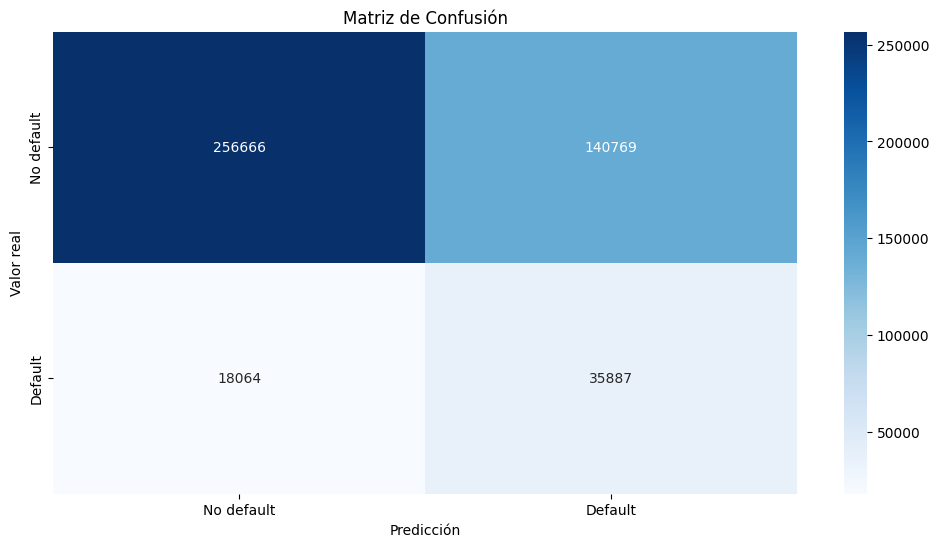

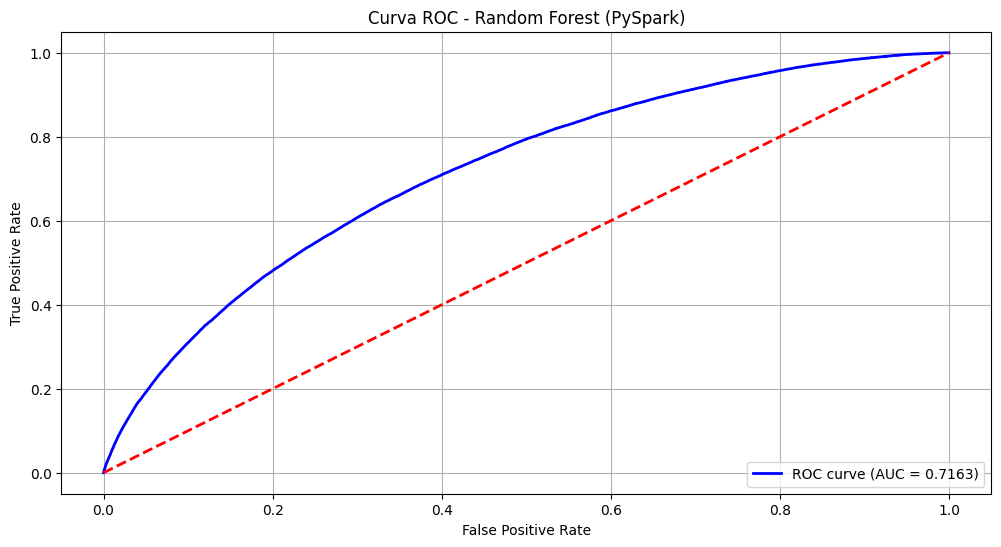

In [66]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues",
            xticklabels=["No default", "Default"],
            yticklabels=["No default", "Default"])

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()

preds_pd = preds.select("label", "probability").toPandas()

preds_pd["prob_pos"] = preds_pd["probability"].apply(lambda x: float(x[1]))

fpr, tpr, thresholds = roc_curve(preds_pd["label"], preds_pd["prob_pos"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest (PySpark)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**1. Accuracy (Exactitud): 0.6481**
- **Mejora del 4.4%** respecto a Scikit-learn (0.622)
- **Interpretación:** Clasifica correctamente el 64.8% de los préstamos
- **Limitación:** Sigue siendo engañosa por el desbalance de clases

**2. Precision (Precisión): 0.2031**
- **Mejora del 7%** vs Scikit-learn (0.190)
- **Interpretación:** Solo **20.3%** de los préstamos identificados como riesgosos son realmente defaults
- **Problema persistente:** Alta tasa de falsos positivos (8 de cada 10 alarmas son incorrectas)

**3. Recall (Sensibilidad): 0.6652**
- **Resultado estable:** Similar a Scikit-learn (0.669)
- **Fortaleza:** Mantiene capacidad de detectar **66.52%** de defaults reales
- **Brecha crítica:** **33.7%** de impagos no detectados

**4. F1-Score: 0.3112**
- **Mejora del 5.2%** vs Scikit-learn (0.296)
- **Indicador clave:** Mejor balance entre Precision y Recall

**Ventajas sobre Scikit-learn:**
- **Mejor desempeño general** en todas las métricas
- **Manejo más eficiente** del desbalance de clases
- **Procesamiento distribuido** permite mejor escalabilidad

**Problemas persistentes:**
- **Precision aún muy baja** (20.3%)
- **Alto costo operativo** por falsos positivos
- **Brecha de detección** significativa (33.7% de defaults no identificados)

**Conclusión:** PySpark muestra **ventajas técnicas** sobre Scikit-learn, pero el modelo aún requiere **optimización urgente** antes de implementación productiva, especialmente en la reducción de falsos positivos que impactan la experiencia del cliente y los costos operativos.